--- Loading & Preprocessing ---
Successfully loaded s4_full.mat
Variables in .mat file: ['__header__', '__version__', '__globals__', 'dsfilt_emg', 'finger_kinematics', 'joint_angles']
Processing data for 5 trials and 7 tasks...
Successfully extracted 35 data segments.
Creating windows with size 200 and step 10...
Created 13335 windows in total.
Train shapes: X=(10668, 200, 8), y=(10668, 14)
Test shapes: X=(2667, 200, 8), y=(2667, 14)
Normalizing data using training set statistics...
Normalization complete.

--- Predictor Model Training/Loading ---
Predictor model filename: emg_angle_model_mlp_w200.keras
Loading existing predictor model...
Predictor model loaded.

--- VAE Model Training/Loading ---
Building and training new VAE model...
Model: "encoder"
____________________________________________________________________________________________________
 Layer (type)                    Output Shape          Param #     Connected to                     
 input_1 (InputLayer)            [(

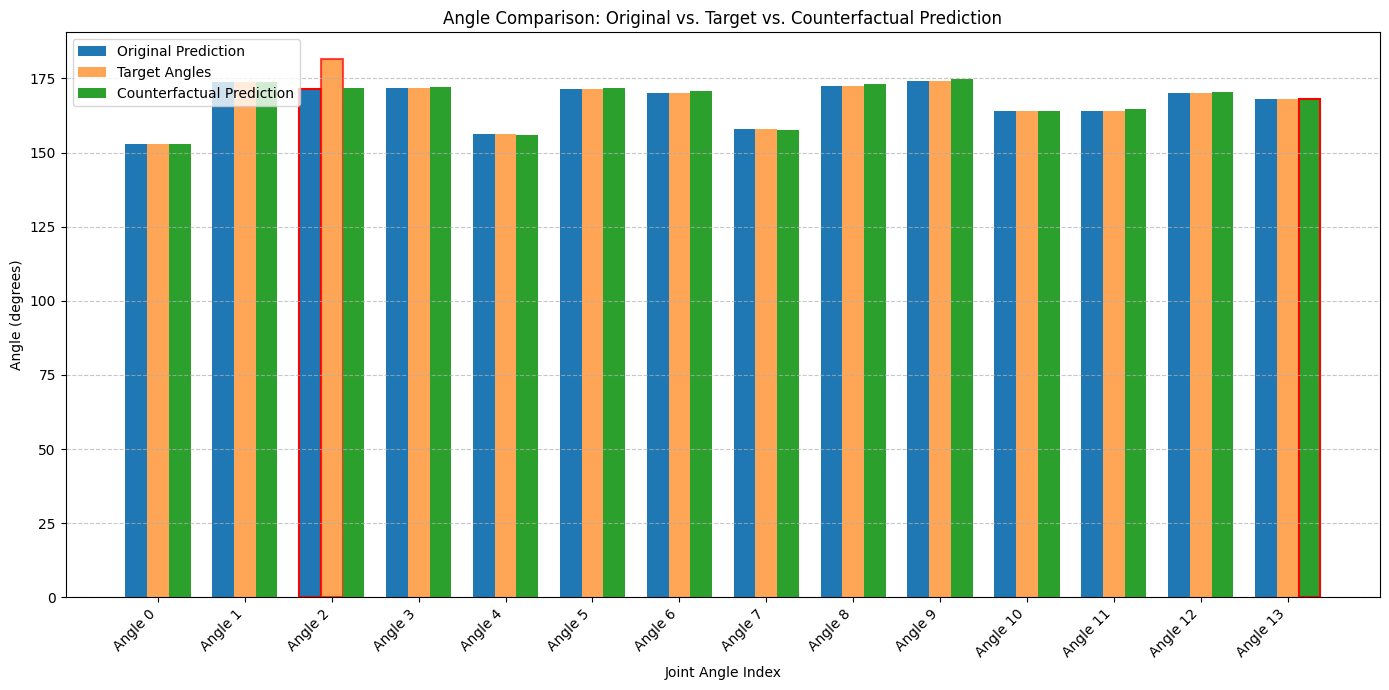

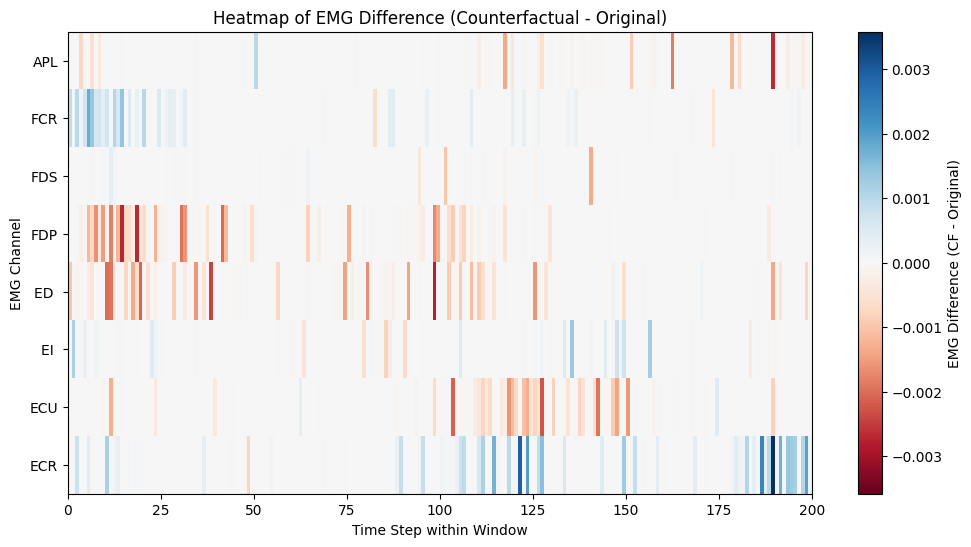

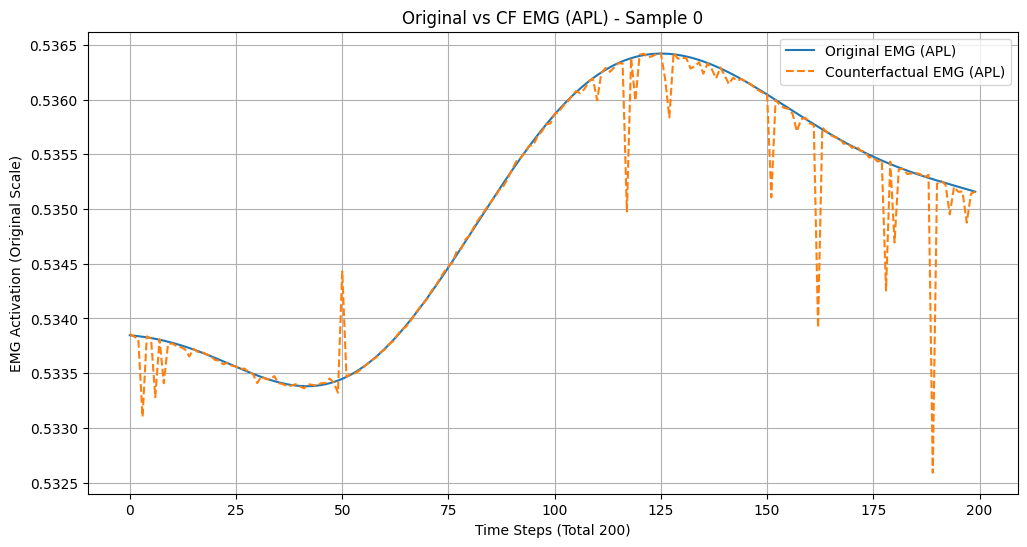

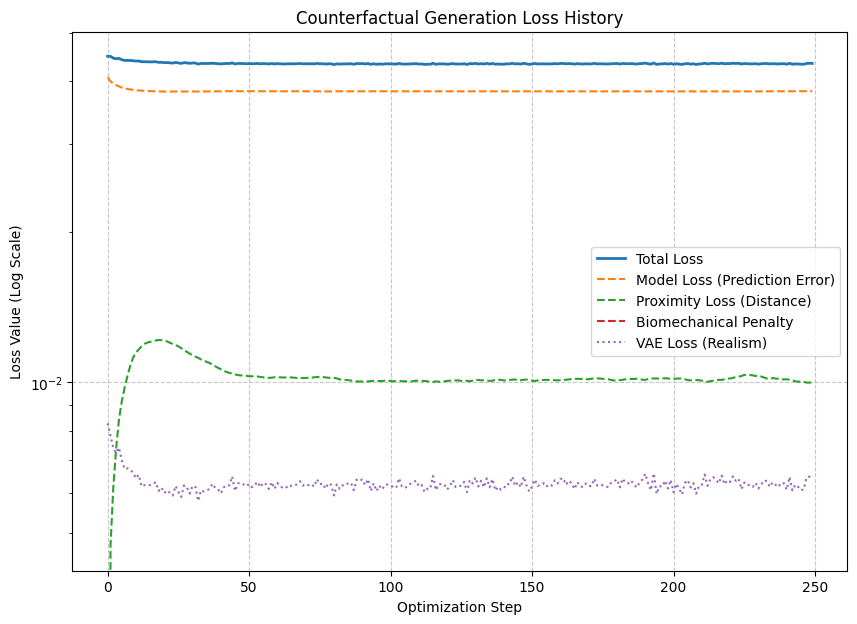

In [1]:
# -*- coding: utf-8 -*-
"""
Estimate joint angles from EMG using a neural network and generate
counterfactual explanations with biomechanical plausibility constraints,
guided by a Variational Autoencoder (VAE) for EMG realism.

(v7: Integrated VAE for EMG realism penalty)
"""

import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import warnings
import time # To time the counterfactual generation

# Suppress TensorFlow warnings for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings('ignore', category=FutureWarning)


# --- 1. Data Loading and Preprocessing ---
# (Functions load_mat_data, create_windowed_data, normalize_data,
#  inverse_normalize_angles, inverse_normalize_emg remain the same)

def load_mat_data(filepath):
    """ Loads EMG and joint angle data from the specified .mat file. """
    try:
        mat_data = scipy.io.loadmat(filepath)
        print(f"Successfully loaded {filepath}")
        print("Variables in .mat file:", list(mat_data.keys()))
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None, None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None, None

    if 'dsfilt_emg' not in mat_data or 'joint_angles' not in mat_data:
        print("Error: Required variables ('dsfilt_emg', 'joint_angles') not found.")
        return None, None

    emg_cells = mat_data['dsfilt_emg']
    angle_cells = mat_data['joint_angles']

    if emg_cells.shape != angle_cells.shape:
        print(f"Warning: Cell shapes differ: EMG {emg_cells.shape}, Angles {angle_cells.shape}.")
        if emg_cells.size != angle_cells.size:
             print("Error: Different number of elements. Cannot proceed.")
             return None, None

    all_emg_data, all_angle_data = [], []
    num_trials, num_tasks = emg_cells.shape
    print(f"Processing data for {num_trials} trials and {num_tasks} tasks...")

    for i in range(num_trials):
        for j in range(num_tasks):
            try:
                emg = emg_cells[i, j]
                angle = angle_cells[i, j]
                if not isinstance(emg, np.ndarray) or not isinstance(angle, np.ndarray) \
                   or emg.ndim != 2 or angle.ndim != 2 \
                   or emg.shape[0] != angle.shape[0] \
                   or emg.shape[1] != 8 or angle.shape[1] != 14:
                    continue
                all_emg_data.append(emg.astype(np.float32))
                all_angle_data.append(angle.astype(np.float32))
            except Exception as e:
                 print(f"Error processing cell ({i},{j}): {e}")

    if not all_emg_data:
        print("Error: No valid data segments extracted.")
        return None, None

    print(f"Successfully extracted {len(all_emg_data)} data segments.")
    return all_emg_data, all_angle_data


def create_windowed_data(emg_list, angle_list, window_size, step=1):
    """ Creates windowed EMG data and corresponding target angles. """
    all_X, all_y = [], []
    total_windows = 0
    if len(emg_list) != len(angle_list):
        print("Error: EMG and Angle lists have different lengths.")
        return None, None

    print(f"Creating windows with size {window_size} and step {step}...")
    for idx, (emg, angle) in enumerate(zip(emg_list, angle_list)):
        if emg.shape[0] < window_size: continue
        segment_len = emg.shape[0]
        for i in range(0, segment_len - window_size + 1, step):
            all_X.append(emg[i : i + window_size, :])
            all_y.append(angle[i + window_size - 1, :])
            total_windows += 1

    if not all_X:
        print(f"Error: No windows created with window size {window_size}.")
        return None, None

    print(f"Created {total_windows} windows in total.")
    return np.array(all_X), np.array(all_y)


def normalize_data(X_train, X_test, y_train, y_test):
    """ Normalizes EMG and angle data using training set statistics. """
    print("Normalizing data using training set statistics...")
    # EMG
    emg_mean = np.mean(X_train, axis=(0, 1), keepdims=True)
    emg_std = np.std(X_train, axis=(0, 1), keepdims=True)
    emg_std = np.where(emg_std < 1e-6, 1e-6, emg_std)
    X_train_norm = (X_train - emg_mean) / emg_std
    X_test_norm = (X_test - emg_mean) / emg_std

    # Angles
    angle_mean = np.mean(y_train, axis=0, keepdims=True)
    angle_std = np.std(y_train, axis=0, keepdims=True)
    angle_std = np.where(angle_std < 1e-6, 1e-6, angle_std)
    y_train_norm = (y_train - angle_mean) / angle_std
    y_test_norm = (y_test - angle_mean) / angle_std

    scalers = {
        'emg_mean': np.squeeze(emg_mean), 'emg_std': np.squeeze(emg_std),
        'angle_mean': np.squeeze(angle_mean), 'angle_std': np.squeeze(angle_std)
    }
    print("Normalization complete.")
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm, scalers

def inverse_normalize_angles(y_norm, scalers):
    """ Inverse transforms normalized angles back to original scale. """
    mean = scalers['angle_mean'].reshape(1, -1)
    std = scalers['angle_std'].reshape(1, -1)
    std = np.where(std < 1e-6, 1e-6, std)
    return (y_norm * std) + mean

def inverse_normalize_emg(X_norm, scalers):
    """ Inverse transforms normalized EMG back to original scale. """
    mean = scalers['emg_mean'].reshape(1, 1, -1)
    std = scalers['emg_std'].reshape(1, 1, -1)
    std = np.where(std < 1e-6, 1e-6, std)
    return (X_norm * std) + mean


# --- 2. EMG -> Angle Model Building and Training ---

def build_mlp_model(input_shape, output_units):
    """ Builds a simple MLP model for EMG->Angle prediction. """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape), layers.Flatten(),
            layers.Dense(128, activation="relu", name="dense_1"), layers.Dropout(0.2),
            layers.Dense(64, activation="relu", name="dense_2"), layers.Dropout(0.2),
            layers.Dense(output_units, name="output_layer"),
        ], name="MLP_Predictor"
    )
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model

def build_lstm_model(input_shape, output_units):
    """ Builds a simple LSTM model for EMG->Angle prediction. """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.LSTM(64, return_sequences=True, name="lstm_1"), layers.Dropout(0.2),
            layers.LSTM(32, name="lstm_2"), layers.Dropout(0.2),
            layers.Dense(output_units, name="output_layer"),
        ], name="LSTM_Predictor"
    )
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model


# --- 3. VAE Model for EMG Realism ---

# Sampling layer for VAE using reparameterization trick
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae(input_shape, latent_dim=16, kl_weight=0.001):
    """ Builds Encoder, Decoder, and VAE model. """
    window_size, n_channels = input_shape

    # --- Encoder ---
    encoder_inputs = keras.Input(shape=input_shape)
    # Optional: Use Conv1D or LSTM layers for temporal features
    # x = layers.LSTM(64, return_sequences=True)(encoder_inputs)
    # x = layers.LSTM(32)(x)
    x = layers.Flatten()(encoder_inputs)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    # --- Decoder ---
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation="relu")(latent_inputs)
    x = layers.Dense(128, activation="relu")(x)
    # Reshape to match the target output shape (window_size * n_channels)
    x = layers.Dense(window_size * n_channels, activation="linear")(x) # Linear activation for regression
    decoder_outputs = layers.Reshape((window_size, n_channels))(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

    # --- VAE Model ---
    class VAE(keras.Model):
        def __init__(self, encoder, decoder, kl_weight, **kwargs):
            super().__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
            self.kl_weight = kl_weight
            self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
            self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
            self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        @property
        def metrics(self):
            return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

        def train_step(self, data):
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(data)
                reconstruction = self.decoder(z)
                # Reconstruction loss (MSE)
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(keras.losses.mean_squared_error(data, reconstruction), axis=(1)) # Sum over window/channels
                )
                # KL divergence loss
                kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
                kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1)) # Sum over latent dim
                # Total loss
                total_loss = reconstruction_loss + self.kl_weight * kl_loss

            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {m.name: m.result() for m in self.metrics}

        # Add call method for inference (reconstruction)
        def call(self, inputs):
             z_mean, z_log_var, z = self.encoder(inputs)
             reconstruction = self.decoder(z)
             return reconstruction


    # Instantiate VAE model
    vae = VAE(encoder, decoder, kl_weight)
    vae.compile(optimizer=keras.optimizers.Adam())
    return vae, encoder, decoder


# --- 4. Counterfactual Generation (with VAE penalty) ---

def get_physiological_bounds(emg_data_list):
    """ Determines approximate min/max physiological bounds from the data. """
    if not emg_data_list: return np.zeros(8), np.ones(8) * 5
    try:
        full_emg = np.concatenate(emg_data_list, axis=0)
        if full_emg.size == 0: return np.zeros(8), np.ones(8) * 5
        min_b = np.min(full_emg, axis=0)
        max_b = np.max(full_emg, axis=0)
        print(f"Calculated EMG Bounds (Min): {min_b}")
        print(f"Calculated EMG Bounds (Max): {max_b}")
        return min_b, max_b
    except ValueError as e: print(f"Error calculating bounds: {e}"); return np.zeros(8), np.ones(8) * 5

def biomechanical_penalty_np(emg_window_orig, agonist_antagonist_pairs):
    """ Calculates biomechanical penalty using NumPy (original scale). """
    penalty = 0.0
    if emg_window_orig.ndim != 2 or emg_window_orig.shape[0] == 0: return penalty
    mean_activation = np.mean(emg_window_orig, axis=0)
    activation_threshold = 0.7 # Placeholder - adjust!
    num_channels = emg_window_orig.shape[1]
    for ag, ant in agonist_antagonist_pairs:
        if ag < num_channels and ant < num_channels:
            if mean_activation[ag] > activation_threshold and mean_activation[ant] > activation_threshold:
                 penalty += 1.0
    return penalty


# Counterfactual generation function now includes VAE
def generate_counterfactual_no_tf_func(predictor_model, vae_model, # Pass VAE model
                                       x_original_norm, y_target_norm, scalers,
                                       lambda_model=1.0, lambda_prox=0.1, lambda_bio=0.5, lambda_vae=0.1, # Added lambda_vae
                                       learning_rate=0.01, steps=100,
                                       emg_min_bounds=None, emg_max_bounds=None,
                                       agonist_antagonist_pairs=None):
    """
    Generates counterfactual EMG using gradient descent, including VAE realism loss.
    Returns the counterfactual EMG and the history of loss components.
    """
    start_time = time.time()
    loss_history = {'total': [], 'model': [], 'prox': [], 'bio': [], 'vae': []} # Added vae loss

    # --- Initial Setup ---
    x_cf_var = tf.Variable(x_original_norm.astype(np.float32), trainable=True, name="x_cf")
    y_target_tf = tf.constant(y_target_norm, dtype=tf.float32, name="y_target")
    x_original_tf = tf.constant(x_original_norm, dtype=tf.float32, name="x_original")

    # --- Prepare bounds in normalized space ---
    emg_min_norm_tf, emg_max_norm_tf = None, None
    if emg_min_bounds is not None and emg_max_bounds is not None:
        emg_mean = scalers['emg_mean'].astype(np.float32)
        emg_std = scalers['emg_std'].astype(np.float32)
        emg_std = np.where(emg_std < 1e-6, 1e-6, emg_std)
        min_norm = (emg_min_bounds.astype(np.float32) - emg_mean) / emg_std
        max_norm = (emg_max_bounds.astype(np.float32) - emg_mean) / emg_std
        emg_min_norm_tf = tf.constant(min_norm, dtype=tf.float32, name="min_bound_norm")
        emg_max_norm_tf = tf.constant(max_norm, dtype=tf.float32, name="max_bound_norm")

    # --- Optimizer ---
    optimizer = tf.keras.optimizers.Adam(learning_rate)

    print("Starting counterfactual generation (step-by-step with VAE)...")
    # --- Optimization Loop ---
    for i in range(steps):
        try:
            with tf.GradientTape() as tape:
                tape.watch(x_cf_var)

                # 1. Model Prediction Loss (Predictor Model)
                y_pred_cf = predictor_model(tf.expand_dims(x_cf_var, axis=0), training=False)[0]
                loss_model = tf.reduce_mean(tf.square(y_pred_cf - y_target_tf))

                # 2. Proximity Loss (L1 norm)
                loss_prox = tf.reduce_mean(tf.abs(x_cf_var - x_original_tf))

                # 3. Biomechanical Plausibility Loss (NumPy calculation)
                loss_bio_val = 0.0
                if agonist_antagonist_pairs is not None and lambda_bio > 0:
                    current_x_cf_norm = x_cf_var.numpy()
                    current_x_cf_orig_batched = inverse_normalize_emg(np.expand_dims(current_x_cf_norm, axis=0), scalers)
                    loss_bio_val = biomechanical_penalty_np(current_x_cf_orig_batched[0], agonist_antagonist_pairs)
                loss_bio = tf.constant(loss_bio_val, dtype=tf.float32)

                # 4. VAE Realism Loss (Reconstruction Error)
                loss_vae_val = 0.0
                if vae_model is not None and lambda_vae > 0:
                    # Calculate VAE reconstruction error for the current counterfactual
                    x_cf_reconstructed = vae_model(tf.expand_dims(x_cf_var, axis=0), training=False)[0]
                    # MSE between current CF and its reconstruction by VAE
                    loss_vae_val = tf.reduce_mean(tf.square(x_cf_var - x_cf_reconstructed))
                loss_vae = tf.constant(loss_vae_val, dtype=tf.float32)

                # Total Loss: Weighted sum including VAE loss
                total_loss = (lambda_model * loss_model +
                              lambda_prox * loss_prox +
                              lambda_bio * loss_bio +
                              lambda_vae * loss_vae) # Added VAE term

            # Calculate gradients
            grads = tape.gradient(total_loss, x_cf_var)
            if grads is None: print(f"Warning: Gradients None at step {i}. Stopping."); break

            # Apply gradients
            optimizer.apply_gradients([(grads, x_cf_var)])

            # Apply Hard Constraints (Clipping)
            if emg_min_norm_tf is not None and emg_max_norm_tf is not None:
                 x_cf_var.assign(tf.clip_by_value(x_cf_var, emg_min_norm_tf, emg_max_norm_tf))

            # Store loss history
            loss_history['total'].append(total_loss.numpy())
            loss_history['model'].append(loss_model.numpy())
            loss_history['prox'].append(loss_prox.numpy())
            loss_history['bio'].append(loss_bio.numpy())
            loss_history['vae'].append(loss_vae.numpy()) # Store VAE loss

            # Print progress
            if (i + 1) % (steps // 10 or 1) == 0:
                 print(f"Step {i+1}/{steps}, Loss: {total_loss.numpy():.4f} "
                       f"(M: {loss_model.numpy():.3f}, P: {loss_prox.numpy():.3f}, B: {loss_bio.numpy():.3f}, V: {loss_vae.numpy():.3f})") # Added VAE loss

        except Exception as e: print(f"Error during optimization step {i}: {e}"); break

    # --- Return Result ---
    final_x_cf = x_cf_var.numpy()
    end_time = time.time()
    print(f"Counterfactual generation finished in {end_time - start_time:.2f} seconds.")
    return final_x_cf, loss_history


# --- 5. Visualization Functions ---
# (plot_angle_comparison, plot_emg_difference_heatmap remain the same)
def plot_angle_comparison(y_pred_orig, y_target, y_pred_cf, target_angle_index):
    """ Plots original, target, and counterfactual predicted angles. """
    n_angles = len(y_pred_orig)
    indices = np.arange(n_angles)
    bar_width = 0.25
    fig, ax = plt.subplots(figsize=(14, 7))
    bar1 = ax.bar(indices - bar_width, y_pred_orig, bar_width, label='Original Prediction')
    bar2 = ax.bar(indices, y_target, bar_width, label='Target Angles', alpha=0.7)
    bar3 = ax.bar(indices + bar_width, y_pred_cf, bar_width, label='Counterfactual Prediction')
    ax.set_xlabel('Joint Angle Index'); ax.set_ylabel('Angle (degrees)')
    ax.set_title('Angle Comparison: Original vs. Target vs. Counterfactual Prediction')
    ax.set_xticks(indices); ax.set_xticklabels([f'Angle {i}' for i in range(n_angles)], rotation=45, ha="right")
    ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.7)
    # Highlight target angle bars
    for bar_idx in [target_angle_index - n_angles, target_angle_index, target_angle_index + n_angles]:
        ax.get_children()[bar_idx].set_edgecolor('red'); ax.get_children()[bar_idx].set_linewidth(1.5)
    fig.tight_layout(); plt.show()

def plot_emg_difference_heatmap(x_orig, x_cf, muscle_names):
    """ Plots a heatmap of the difference between original and counterfactual EMG. """
    if x_orig.shape != x_cf.shape or x_orig.ndim != 2: return
    emg_diff = x_cf - x_orig
    window_size, n_channels = emg_diff.shape
    plt.figure(figsize=(12, 6))
    lim = np.max(np.abs(emg_diff)); lim = max(lim, 1e-6) # Avoid zero limit
    plt.imshow(emg_diff.T, aspect='auto', cmap='RdBu', vmin=-lim, vmax=lim, extent=[0, window_size, n_channels-0.5, -0.5])
    plt.colorbar(label='EMG Difference (CF - Original)'); plt.yticks(np.arange(n_channels), muscle_names)
    plt.xlabel('Time Step within Window'); plt.ylabel('EMG Channel')
    plt.title('Heatmap of EMG Difference (Counterfactual - Original)'); plt.show()

# Updated plot_loss_history to include VAE loss
def plot_loss_history(loss_history):
    """ Plots the history of loss components during counterfactual generation. """
    plt.figure(figsize=(10, 7)) # Slightly taller figure
    steps = range(len(loss_history['total']))
    plt.plot(steps, loss_history['total'], label='Total Loss', linewidth=2)
    plt.plot(steps, loss_history['model'], label='Model Loss (Prediction Error)', linestyle='--')
    plt.plot(steps, loss_history['prox'], label='Proximity Loss (Distance)', linestyle='--')
    plt.plot(steps, loss_history['bio'], label='Biomechanical Penalty', linestyle='--')
    plt.plot(steps, loss_history['vae'], label='VAE Loss (Realism)', linestyle=':') # Added VAE loss plot
    plt.xlabel('Optimization Step'); plt.ylabel('Loss Value (Log Scale)')
    plt.title('Counterfactual Generation Loss History')
    plt.yscale('log') # Use log scale for better visibility if losses differ greatly
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7); plt.show()


# --- 6. Main Execution ---

if __name__ == "__main__":
    # --- Configuration ---
    MAT_FILE_PATH = 's4_full.mat' # <<< SET YOUR PATH HERE
    WINDOW_SIZE = 200
    STEP_SIZE = 10
    TEST_SPLIT = 0.2
    USE_LSTM_PREDICTOR = False # Choose MLP or LSTM for EMG->Angle model
    EPOCHS_PREDICTOR = 25
    BATCH_SIZE_PREDICTOR = 32

    # --- VAE Configuration ---
    TRAIN_VAE = True # Set to False to load existing VAE if available
    VAE_LATENT_DIM = 16 # Dimensionality of VAE latent space
    VAE_EPOCHS = 30 # Adjust VAE training epochs
    VAE_BATCH_SIZE = 64
    VAE_KL_WEIGHT = 0.001 # Weight for KL divergence term in VAE loss

    # --- Counterfactual Params ---
    CF_LAMBDA_MODEL = 1.0
    CF_LAMBDA_PROX = 0.2
    CF_LAMBDA_BIO = 1.0
    CF_LAMBDA_VAE = 0.5   # <<< Weight for VAE realism loss (tune this!)
    CF_LEARNING_RATE = 0.005
    CF_STEPS = 250

    # --- Data Loading & Preprocessing ---
    print("--- Loading & Preprocessing ---")
    # ...(Data loading logic)...
    if not os.path.exists(MAT_FILE_PATH):
         print(f"Error: File not found at {MAT_FILE_PATH}"); exit() # Simplified exit
    all_emg, all_angles = load_mat_data(MAT_FILE_PATH)
    if all_emg is None: exit()
    # ...(Preprocessing logic)...
    X, y = create_windowed_data(all_emg, all_angles, WINDOW_SIZE, STEP_SIZE)
    if X is None: exit()
    indices = np.arange(X.shape[0]); np.random.shuffle(indices); X, y = X[indices], y[indices]
    split_idx = int(X.shape[0] * (1 - TEST_SPLIT))
    if split_idx <= 0 or split_idx >= X.shape[0]: print(f"Warning: Invalid train/test split."); split_idx = max(1, int(X.shape[0] * 0.8))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
    print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")
    if X_train.shape[0] == 0 or X_test.shape[0] == 0: print("Error: Train/Test set empty."); exit()
    X_train_norm, X_test_norm, y_train_norm, y_test_norm, scalers = normalize_data(X_train, X_test, y_train, y_test)

    # --- Predictor Model Training/Loading ---
    print("\n--- Predictor Model Training/Loading ---")
    input_shape_pred = X_train_norm.shape[1:] # (window_size, n_channels)
    output_units_pred = y_train_norm.shape[1] # n_angles
    predictor_model_filename = f"emg_angle_model_{'lstm' if USE_LSTM_PREDICTOR else 'mlp'}_w{WINDOW_SIZE}.keras"
    print(f"Predictor model filename: {predictor_model_filename}")
    if os.path.exists(predictor_model_filename):
        print(f"Loading existing predictor model...")
        try:
            predictor_model = keras.models.load_model(predictor_model_filename, compile=True)
            if predictor_model.input_shape[1:] != input_shape_pred: print(f"Predictor shape mismatch. Retraining."); predictor_model = None
            else: print("Predictor model loaded.")
        except Exception as e: print(f"Error loading predictor: {e}. Training new."); predictor_model = None
    else: predictor_model = None; print(f"Predictor model not found. Training new.")

    if predictor_model is None:
        predictor_model = build_lstm_model(input_shape_pred, output_units_pred) if USE_LSTM_PREDICTOR else build_mlp_model(input_shape_pred, output_units_pred)
        predictor_model.summary(line_length=100)
        early_stopping_pred = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
        print("Starting predictor model training...")
        predictor_model.fit( X_train_norm, y_train_norm, epochs=EPOCHS_PREDICTOR, batch_size=BATCH_SIZE_PREDICTOR, validation_split=0.15, callbacks=[early_stopping_pred], verbose=1 )
        print("Predictor model training finished.")
        try: predictor_model.save(predictor_model_filename); print(f"Predictor model saved.")
        except Exception as e: print(f"Error saving predictor model: {e}")

    # --- VAE Model Training/Loading ---
    print("\n--- VAE Model Training/Loading ---")
    vae_model_filename = f"emg_vae_model_w{WINDOW_SIZE}_ld{VAE_LATENT_DIM}.keras"
    vae_model, encoder, decoder = None, None, None # Initialize

    if not TRAIN_VAE and os.path.exists(vae_model_filename):
        print(f"Loading existing VAE model from {vae_model_filename}...")
        try:
            # Load the full VAE model (contains encoder and decoder)
            vae_model = keras.models.load_model(vae_model_filename, custom_objects={'VAE': VAE, 'Sampling': Sampling}, compile=False) # Don't compile here if just using for inference
            # Optionally recompile if needed later, e.g., vae_model.compile(optimizer=keras.optimizers.Adam())
            # Extract encoder/decoder if needed separately (though VAE call method works)
            encoder = vae_model.encoder
            decoder = vae_model.decoder
            print("VAE model loaded successfully.")
        except Exception as e:
            print(f"Error loading VAE model: {e}. Will attempt to train.")
            TRAIN_VAE = True # Force training if loading failed
            vae_model = None # Reset
    elif not TRAIN_VAE:
         print(f"VAE model file {vae_model_filename} not found, but TRAIN_VAE is False. Cannot proceed without VAE.")
         exit() # Or force training: TRAIN_VAE = True

    if TRAIN_VAE or vae_model is None:
        print("Building and training new VAE model...")
        input_shape_vae = X_train_norm.shape[1:] # Should be same as predictor input shape
        vae_model, encoder, decoder = build_vae(input_shape_vae, latent_dim=VAE_LATENT_DIM, kl_weight=VAE_KL_WEIGHT)
        vae_model.encoder.summary(line_length=100)
        vae_model.decoder.summary(line_length=100)

        print("Starting VAE training...")
        # Train VAE only on the EMG data (X_train_norm)
        vae_model.fit(X_train_norm, epochs=VAE_EPOCHS, batch_size=VAE_BATCH_SIZE, validation_split=0.1, verbose=1)
        print("VAE training finished.")
        try:
            vae_model.save(vae_model_filename)
            print(f"VAE model saved to {vae_model_filename}")
        except Exception as e:
            print(f"Error saving VAE model: {e}")

    # Ensure we have a vae_model object for counterfactual generation
    if vae_model is None:
         print("Error: VAE model is not available after training/loading attempt.")
         exit()


    # --- Predictor Model Evaluation ---
    print("\n--- Predictor Model Evaluation ---")
    # ...(Evaluation logic remains the same)...
    if X_test_norm.shape[0] > 0:
        test_loss = predictor_model.evaluate(X_test_norm, y_test_norm, verbose=0)
        print(f"Predictor Test Loss (MSE): {test_loss:.4f}")
        num_preds = min(5, X_test_norm.shape[0])
        y_pred_norm = predictor_model.predict(X_test_norm[:num_preds], verbose=0)
        y_pred = inverse_normalize_angles(y_pred_norm, scalers)
        y_actual = inverse_normalize_angles(y_test_norm[:num_preds], scalers)
        print(f"\nExample Predictions (first {num_preds} test samples):")
        print("Idx | Actual Angle 0 | Predicted Angle 0")
        print("---------------------------------------")
        for i in range(num_preds): print(f"{i:3d} | {y_actual[i, 0]:14.2f} | {y_pred[i, 0]:17.2f}")
    else: print("Skipping predictor evaluation as test set is empty.")


    # --- Counterfactual Generation Example ---
    print("\n--- Counterfactual Generation ---")
    if X_test_norm.shape[0] == 0: print("Test set empty."); exit()

    sample_index = 0
    x_orig_norm = X_test_norm[sample_index]
    y_orig_norm = y_test_norm[sample_index]
    y_pred_orig_norm = predictor_model.predict(np.expand_dims(x_orig_norm, axis=0), verbose=0)[0]

    target_angle_index = 2
    degree_change = 10.0
    y_target_norm = y_pred_orig_norm.copy()
    current_angle_norm = y_target_norm[target_angle_index]
    std_dev = scalers['angle_std'][target_angle_index]
    target_angle_norm = current_angle_norm + (degree_change / (std_dev + 1e-6))
    y_target_norm[target_angle_index] = target_angle_norm

    emg_min_bounds, emg_max_bounds = get_physiological_bounds(all_emg)
    agonist_antagonist_pairs = [(2, 4), (3, 4)] # Placeholder
    print(f"\nUsing simplified Agonist/Antagonist pairs: {agonist_antagonist_pairs}")
    muscle_names = ["APL", "FCR", "FDS", "FDP", "ED ", "EI ", "ECU", "ECR"]
    print(f"(Indices: {', '.join([f'{i}:{name}' for i, name in enumerate(muscle_names)])})")


    # Call counterfactual function, passing the trained VAE model
    x_cf_norm, loss_history = generate_counterfactual_no_tf_func(
        predictor_model, # The EMG->Angle predictor
        vae_model,       # The trained VAE model
        x_orig_norm, y_target_norm, scalers,
        lambda_model=CF_LAMBDA_MODEL, lambda_prox=CF_LAMBDA_PROX, lambda_bio=CF_LAMBDA_BIO, lambda_vae=CF_LAMBDA_VAE, # Pass lambda_vae
        learning_rate=CF_LEARNING_RATE, steps=CF_STEPS,
        emg_min_bounds=emg_min_bounds, emg_max_bounds=emg_max_bounds,
        agonist_antagonist_pairs=agonist_antagonist_pairs
    )

    # --- Evaluate Counterfactual ---
    y_pred_cf_norm = predictor_model.predict(np.expand_dims(x_cf_norm, axis=0), verbose=0)[0]

    # Inverse transform for analysis
    x_orig = inverse_normalize_emg(np.expand_dims(x_orig_norm, axis=0), scalers)[0]
    x_cf = inverse_normalize_emg(np.expand_dims(x_cf_norm, axis=0), scalers)[0]
    y_pred_orig = inverse_normalize_angles(np.expand_dims(y_pred_orig_norm, axis=0), scalers)[0]
    y_target = inverse_normalize_angles(np.expand_dims(y_target_norm, axis=0), scalers)[0]
    y_pred_cf = inverse_normalize_angles(np.expand_dims(y_pred_cf_norm, axis=0), scalers)[0]
    y_actual_sample = inverse_normalize_angles(np.expand_dims(y_orig_norm, axis=0), scalers)[0]

    # --- Enhanced Explanation & Visualization ---
    print("\n--- Counterfactual Results & Explanation ---")
    print(f"Original Sample Index: {sample_index}")
    print(f"Actual Angles:          {np.array2string(y_actual_sample, precision=2, floatmode='fixed')}")
    print(f"Original Prediction:    {np.array2string(y_pred_orig, precision=2, floatmode='fixed')}")
    print(f"Target Angles:          {np.array2string(y_target, precision=2, floatmode='fixed')}")
    print(f"Counterfactual Predict: {np.array2string(y_pred_cf, precision=2, floatmode='fixed')}")

    # Detailed Explanation including VAE
    target_angle_val = y_target[target_angle_index]
    pred_cf_angle_val = y_pred_cf[target_angle_index]
    print("\n** Explanation of Counterfactual Result **")
    print(f"Goal: Change angle {target_angle_index} from {y_pred_orig[target_angle_index]:.1f} deg towards {target_angle_val:.1f} deg.")
    print(f"Result: Found EMG pattern predicting {pred_cf_angle_val:.1f} deg for angle {target_angle_index}.")
    print("This modified EMG is the 'closest' plausible change found, considering:")
    print(f"  - Model Loss (Weight {CF_LAMBDA_MODEL}): Match target prediction.")
    print(f"  - Proximity Loss (Weight {CF_LAMBDA_PROX}): Minimize change from original EMG.")
    print(f"  - Biomechanical Loss (Weight {CF_LAMBDA_BIO}): Penalize implausible co-contractions (e.g., {agonist_antagonist_pairs}).")
    print(f"  - VAE Realism Loss (Weight {CF_LAMBDA_VAE}): Penalize EMG patterns unlikely under the VAE trained on real data (high reconstruction error).") # Added VAE explanation
    print(f"  - Hard Constraints: Enforce EMG min/max bounds.")

    # Analyze EMG change
    emg_diff = x_cf - x_orig
    mean_abs_diff = np.mean(np.abs(emg_diff), axis=0)
    mean_diff = np.mean(emg_diff, axis=0)
    epsilon = 1e-6
    mean_orig_abs = np.mean(np.abs(x_orig), axis=0)
    emg_change_percent = (mean_abs_diff / (mean_orig_abs + epsilon)) * 100

    print("\n** EMG Change Analysis **")
    # ...(Print table remains the same)...
    print("Channel | Mean Abs Diff | Mean Diff | Mean Abs % Change")
    print("--------|---------------|-----------|--------------------")
    for i, name in enumerate(muscle_names): print(f"{name:<7} | {mean_abs_diff[i]:<13.4f} | {mean_diff[i]:<9.4f} | {emg_change_percent[i]:<18.2f}%")
    print("\nInterpretation Hints:")
    print(" - Compare Mean Diff signs/magnitudes with muscle functions (flexor/extensor).")
    print(" - High % Change might indicate significant alteration.")
    print(" - Check heatmap for *when* changes occur within the window.")
    print(" - Check loss plot: Did VAE loss decrease? Did Bio penalty stay low?")
    print("(Accuracy depends on models, constraints, thresholds, and lambda weights).")

    # --- Generate Visualizations ---
    print("\n--- Generating Visualizations ---")
    try:
        # 1. Angle Comparison Plot
        plot_angle_comparison(y_pred_orig, y_target, y_pred_cf, target_angle_index)
        # 2. EMG Difference Heatmap
        plot_emg_difference_heatmap(x_orig, x_cf, muscle_names)
        # 3. Original vs Counterfactual EMG (Example: First Channel)
        plt.figure(figsize=(12, 6)); time_axis = np.arange(x_orig.shape[0])
        plt.plot(time_axis, x_orig[:, 0], label=f'Original EMG ({muscle_names[0]})')
        plt.plot(time_axis, x_cf[:, 0], label=f'Counterfactual EMG ({muscle_names[0]})', linestyle='--')
        plt.title(f'Original vs CF EMG ({muscle_names[0]}) - Sample {sample_index}'); plt.xlabel(f'Time Steps (Total {x_orig.shape[0]})')
        plt.ylabel('EMG Activation (Original Scale)'); plt.legend(); plt.grid(True); plt.show()
        # 4. Loss History Plot (Now includes VAE loss)
        plot_loss_history(loss_history)
    except Exception as e: print(f"Could not generate all plots: {e}")



--- Loading & Preprocessing ---
Successfully loaded s4_full.mat
Variables in .mat file: ['__header__', '__version__', '__globals__', 'dsfilt_emg', 'finger_kinematics', 'joint_angles']
Processing data for 5 trials and 7 tasks...
Successfully extracted 35 data segments.
Creating windows with size 200 and step 10...
Created 13335 windows in total.
Train shapes: X=(10668, 200, 8), y=(10668, 14)
Test shapes: X=(2667, 200, 8), y=(2667, 14)
Normalizing data using training set statistics...
Normalization complete.

--- Predictor Model Training/Loading ---
Predictor model filename: emg_angle_model_mlp_w200.keras
Loading existing predictor model...
Predictor model loaded.

--- GAN Model Training/Loading ---
Building and training new GAN model...
Model: "Generator"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 dense_14 (Dense)                

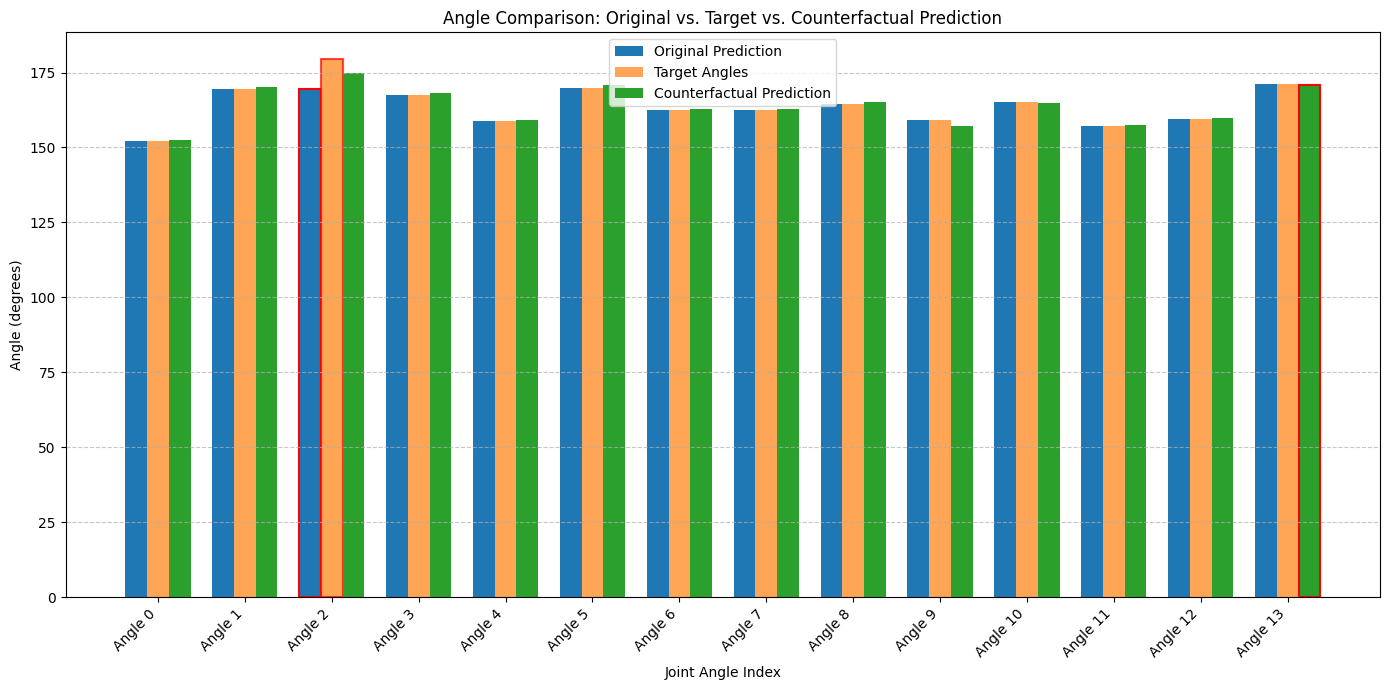

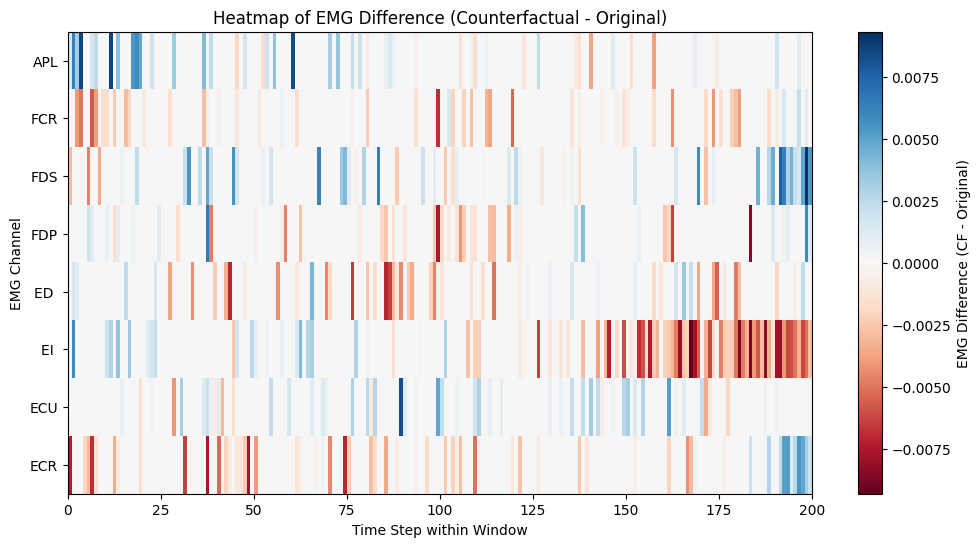

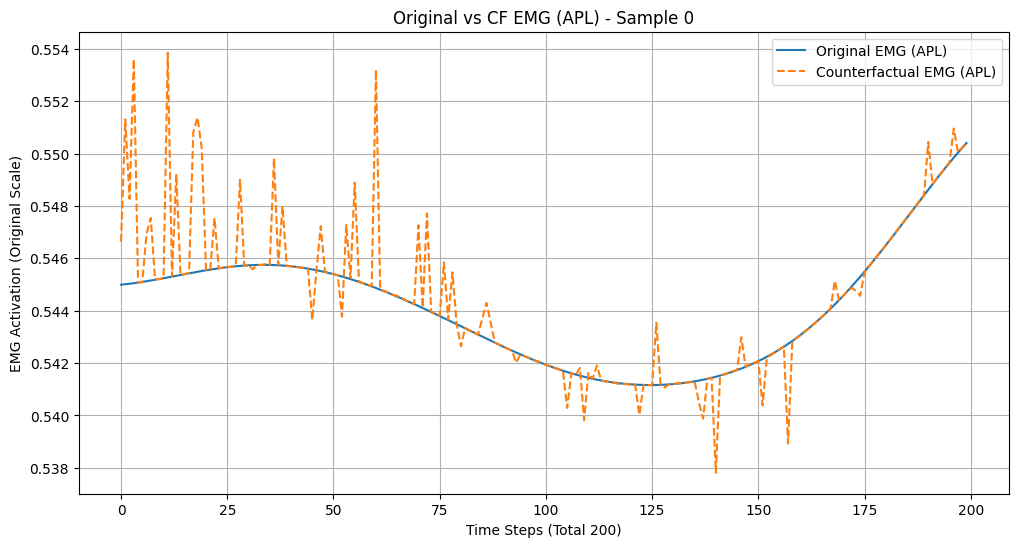

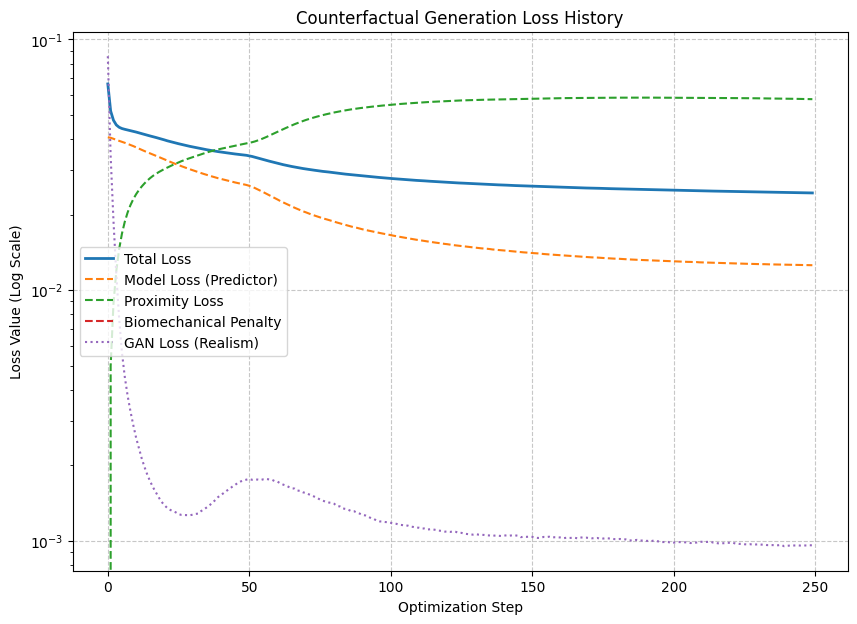

In [12]:
# -*- coding: utf-8 -*-
"""
Estimate joint angles from EMG using a neural network and generate
counterfactual explanations with biomechanical plausibility constraints,
guided by a Generative Adversarial Network (GAN) for EMG realism.

(v8: Replaced VAE with GAN for EMG realism penalty)
"""

import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import warnings
import time # To time the counterfactual generation

# Suppress TensorFlow warnings for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings('ignore', category=FutureWarning)


# --- 1. Data Loading and Preprocessing ---
# (Functions load_mat_data, create_windowed_data, normalize_data,
#  inverse_normalize_angles, inverse_normalize_emg remain the same)
# ... (Keep functions from previous version) ...
def load_mat_data(filepath):
    """ Loads EMG and joint angle data from the specified .mat file. """
    try:
        mat_data = scipy.io.loadmat(filepath)
        print(f"Successfully loaded {filepath}")
        print("Variables in .mat file:", list(mat_data.keys()))
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None, None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None, None

    if 'dsfilt_emg' not in mat_data or 'joint_angles' not in mat_data:
        print("Error: Required variables ('dsfilt_emg', 'joint_angles') not found.")
        return None, None

    emg_cells = mat_data['dsfilt_emg']
    angle_cells = mat_data['joint_angles']

    if emg_cells.shape != angle_cells.shape:
        print(f"Warning: Cell shapes differ: EMG {emg_cells.shape}, Angles {angle_cells.shape}.")
        if emg_cells.size != angle_cells.size:
             print("Error: Different number of elements. Cannot proceed.")
             return None, None

    all_emg_data, all_angle_data = [], []
    num_trials, num_tasks = emg_cells.shape
    print(f"Processing data for {num_trials} trials and {num_tasks} tasks...")

    for i in range(num_trials):
        for j in range(num_tasks):
            try:
                emg = emg_cells[i, j]
                angle = angle_cells[i, j]
                if not isinstance(emg, np.ndarray) or not isinstance(angle, np.ndarray) \
                   or emg.ndim != 2 or angle.ndim != 2 \
                   or emg.shape[0] != angle.shape[0] \
                   or emg.shape[1] != 8 or angle.shape[1] != 14:
                    continue
                all_emg_data.append(emg.astype(np.float32))
                all_angle_data.append(angle.astype(np.float32))
            except Exception as e:
                 print(f"Error processing cell ({i},{j}): {e}")

    if not all_emg_data:
        print("Error: No valid data segments extracted.")
        return None, None

    print(f"Successfully extracted {len(all_emg_data)} data segments.")
    return all_emg_data, all_angle_data


def create_windowed_data(emg_list, angle_list, window_size, step=1):
    """ Creates windowed EMG data and corresponding target angles. """
    all_X, all_y = [], []
    total_windows = 0
    if len(emg_list) != len(angle_list):
        print("Error: EMG and Angle lists have different lengths.")
        return None, None

    print(f"Creating windows with size {window_size} and step {step}...")
    for idx, (emg, angle) in enumerate(zip(emg_list, angle_list)):
        if emg.shape[0] < window_size: continue
        segment_len = emg.shape[0]
        for i in range(0, segment_len - window_size + 1, step):
            all_X.append(emg[i : i + window_size, :])
            all_y.append(angle[i + window_size - 1, :])
            total_windows += 1

    if not all_X:
        print(f"Error: No windows created with window size {window_size}.")
        return None, None

    print(f"Created {total_windows} windows in total.")
    return np.array(all_X), np.array(all_y)


def normalize_data(X_train, X_test, y_train, y_test):
    """ Normalizes EMG and angle data using training set statistics. """
    print("Normalizing data using training set statistics...")
    # EMG
    emg_mean = np.mean(X_train, axis=(0, 1), keepdims=True)
    emg_std = np.std(X_train, axis=(0, 1), keepdims=True)
    emg_std = np.where(emg_std < 1e-6, 1e-6, emg_std)
    X_train_norm = (X_train - emg_mean) / emg_std
    X_test_norm = (X_test - emg_mean) / emg_std

    # Angles
    angle_mean = np.mean(y_train, axis=0, keepdims=True)
    angle_std = np.std(y_train, axis=0, keepdims=True)
    angle_std = np.where(angle_std < 1e-6, 1e-6, angle_std)
    y_train_norm = (y_train - angle_mean) / angle_std
    y_test_norm = (y_test - angle_mean) / angle_std

    scalers = {
        'emg_mean': np.squeeze(emg_mean), 'emg_std': np.squeeze(emg_std),
        'angle_mean': np.squeeze(angle_mean), 'angle_std': np.squeeze(angle_std)
    }
    print("Normalization complete.")
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm, scalers

def inverse_normalize_angles(y_norm, scalers):
    """ Inverse transforms normalized angles back to original scale. """
    mean = scalers['angle_mean'].reshape(1, -1)
    std = scalers['angle_std'].reshape(1, -1)
    std = np.where(std < 1e-6, 1e-6, std)
    return (y_norm * std) + mean

def inverse_normalize_emg(X_norm, scalers):
    """ Inverse transforms normalized EMG back to original scale. """
    mean = scalers['emg_mean'].reshape(1, 1, -1)
    std = scalers['emg_std'].reshape(1, 1, -1)
    std = np.where(std < 1e-6, 1e-6, std)
    return (X_norm * std) + mean


# --- 2. EMG -> Angle Model Building and Training ---
# (Functions build_mlp_model, build_lstm_model remain the same)
# ... (Keep functions from previous version) ...
def build_mlp_model(input_shape, output_units):
    """ Builds a simple MLP model for EMG->Angle prediction. """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape), layers.Flatten(),
            layers.Dense(128, activation="relu", name="dense_1"), layers.Dropout(0.2),
            layers.Dense(64, activation="relu", name="dense_2"), layers.Dropout(0.2),
            layers.Dense(output_units, name="output_layer"),
        ], name="MLP_Predictor"
    )
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model

def build_lstm_model(input_shape, output_units):
    """ Builds a simple LSTM model for EMG->Angle prediction. """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.LSTM(64, return_sequences=True, name="lstm_1"), layers.Dropout(0.2),
            layers.LSTM(32, name="lstm_2"), layers.Dropout(0.2),
            layers.Dense(output_units, name="output_layer"),
        ], name="LSTM_Predictor"
    )
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model


# --- 3. GAN Model for EMG Realism ---

def build_generator(latent_dim, output_shape):
    """ Builds the Generator model. """
    window_size, n_channels = output_shape
    model = keras.Sequential(name="Generator")
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    # Output layer needs to produce window_size * n_channels values
    model.add(layers.Dense(window_size * n_channels, activation='linear')) # Or tanh if data normalized to [-1,1]
    model.add(layers.Reshape(output_shape))
    return model

def build_discriminator(input_shape):
    """ Builds the Discriminator model. """
    model = keras.Sequential(name="Discriminator")
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Flatten())
    # Optional: Add LSTM/Conv1D layers here if needed
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    # Output a single value representing probability of being real
    model.add(layers.Dense(1, activation='sigmoid')) # Sigmoid for standard GAN loss
    return model

# Define GAN losses
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False) # Use from_logits=True if Discriminator has no sigmoid

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    # Generator wants discriminator to output 1 (real) for fake images
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Custom GAN Training Step (simplified example)
# Note: More robust training might involve separate steps or WGAN-GP loss
@tf.function
def gan_train_step(real_emg, generator, discriminator, g_optimizer, d_optimizer, latent_dim, batch_size):
    # Generate noise
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake EMG
        generated_emg = generator(noise, training=True)

        # Get discriminator outputs
        real_output = discriminator(real_emg, training=True)
        fake_output = discriminator(generated_emg, training=True)

        # Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calculate and apply gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return gen_loss, disc_loss


# --- 4. Counterfactual Generation (with GAN penalty) ---

def get_physiological_bounds(emg_data_list):
    """ Determines approximate min/max physiological bounds from the data. """
    if not emg_data_list: return np.zeros(8), np.ones(8) * 5
    try:
        full_emg = np.concatenate(emg_data_list, axis=0)
        if full_emg.size == 0: return np.zeros(8), np.ones(8) * 5
        min_b = np.min(full_emg, axis=0); max_b = np.max(full_emg, axis=0)
        print(f"Calculated EMG Bounds (Min): {min_b}")
        print(f"Calculated EMG Bounds (Max): {max_b}")
        return min_b, max_b
    except ValueError as e: print(f"Error calculating bounds: {e}"); return np.zeros(8), np.ones(8) * 5

def biomechanical_penalty_np(emg_window_orig, agonist_antagonist_pairs):
    """ Calculates biomechanical penalty using NumPy (original scale). """
    penalty = 0.0
    if emg_window_orig.ndim != 2 or emg_window_orig.shape[0] == 0: return penalty
    mean_activation = np.mean(emg_window_orig, axis=0)
    activation_threshold = 0.7 # Placeholder - adjust!
    num_channels = emg_window_orig.shape[1]
    for ag, ant in agonist_antagonist_pairs:
        if ag < num_channels and ant < num_channels:
            if mean_activation[ag] > activation_threshold and mean_activation[ant] > activation_threshold:
                 penalty += 1.0
    return penalty


# Counterfactual generation function now includes GAN discriminator
def generate_counterfactual_no_tf_func(predictor_model, gan_discriminator, # Pass GAN discriminator
                                       x_original_norm, y_target_norm, scalers,
                                       lambda_model=1.0, lambda_prox=0.1, lambda_bio=0.5, lambda_gan=0.1, # Added lambda_gan
                                       learning_rate=0.01, steps=100,
                                       emg_min_bounds=None, emg_max_bounds=None,
                                       agonist_antagonist_pairs=None):
    """
    Generates counterfactual EMG using gradient descent, including GAN realism loss.
    Returns the counterfactual EMG and the history of loss components.
    """
    start_time = time.time()
    loss_history = {'total': [], 'model': [], 'prox': [], 'bio': [], 'gan': []} # Added gan loss

    # --- Initial Setup ---
    x_cf_var = tf.Variable(x_original_norm.astype(np.float32), trainable=True, name="x_cf")
    y_target_tf = tf.constant(y_target_norm, dtype=tf.float32, name="y_target")
    x_original_tf = tf.constant(x_original_norm, dtype=tf.float32, name="x_original")

    # --- Prepare bounds in normalized space ---
    emg_min_norm_tf, emg_max_norm_tf = None, None
    if emg_min_bounds is not None and emg_max_bounds is not None:
        emg_mean = scalers['emg_mean'].astype(np.float32)
        emg_std = scalers['emg_std'].astype(np.float32)
        emg_std = np.where(emg_std < 1e-6, 1e-6, emg_std)
        min_norm = (emg_min_bounds.astype(np.float32) - emg_mean) / emg_std
        max_norm = (emg_max_bounds.astype(np.float32) - emg_mean) / emg_std
        emg_min_norm_tf = tf.constant(min_norm, dtype=tf.float32, name="min_bound_norm")
        emg_max_norm_tf = tf.constant(max_norm, dtype=tf.float32, name="max_bound_norm")

    # --- Optimizer ---
    optimizer = tf.keras.optimizers.Adam(learning_rate)

    print("Starting counterfactual generation (step-by-step with GAN)...")
    # --- Optimization Loop ---
    for i in range(steps):
        try:
            with tf.GradientTape() as tape:
                tape.watch(x_cf_var)

                # 1. Model Prediction Loss (Predictor Model)
                y_pred_cf = predictor_model(tf.expand_dims(x_cf_var, axis=0), training=False)[0]
                loss_model = tf.reduce_mean(tf.square(y_pred_cf - y_target_tf))

                # 2. Proximity Loss (L1 norm)
                loss_prox = tf.reduce_mean(tf.abs(x_cf_var - x_original_tf))

                # 3. Biomechanical Plausibility Loss (NumPy calculation)
                loss_bio_val = 0.0
                if agonist_antagonist_pairs is not None and lambda_bio > 0:
                    current_x_cf_norm = x_cf_var.numpy()
                    current_x_cf_orig_batched = inverse_normalize_emg(np.expand_dims(current_x_cf_norm, axis=0), scalers)
                    loss_bio_val = biomechanical_penalty_np(current_x_cf_orig_batched[0], agonist_antagonist_pairs)
                loss_bio = tf.constant(loss_bio_val, dtype=tf.float32)

                # 4. GAN Realism Loss (Discriminator Output)
                loss_gan_val = 0.0
                if gan_discriminator is not None and lambda_gan > 0:
                    # Get discriminator's prediction for the current counterfactual
                    # We want the discriminator to output 1 (real)
                    disc_pred_cf = gan_discriminator(tf.expand_dims(x_cf_var, axis=0), training=False)[0]
                    # Calculate loss as BCE against target "1" (real)
                    loss_gan_val = cross_entropy(tf.ones_like(disc_pred_cf), disc_pred_cf)
                loss_gan = tf.constant(loss_gan_val, dtype=tf.float32)

                # Total Loss: Weighted sum including GAN loss
                total_loss = (lambda_model * loss_model +
                              lambda_prox * loss_prox +
                              lambda_bio * loss_bio +
                              lambda_gan * loss_gan) # Added GAN term

            # Calculate gradients
            grads = tape.gradient(total_loss, x_cf_var)
            if grads is None: print(f"Warning: Gradients None at step {i}. Stopping."); break

            # Apply gradients
            optimizer.apply_gradients([(grads, x_cf_var)])

            # Apply Hard Constraints (Clipping)
            if emg_min_norm_tf is not None and emg_max_norm_tf is not None:
                 x_cf_var.assign(tf.clip_by_value(x_cf_var, emg_min_norm_tf, emg_max_norm_tf))

            # Store loss history
            loss_history['total'].append(total_loss.numpy())
            loss_history['model'].append(loss_model.numpy())
            loss_history['prox'].append(loss_prox.numpy())
            loss_history['bio'].append(loss_bio.numpy())
            loss_history['gan'].append(loss_gan.numpy()) # Store GAN loss

            # Print progress
            if (i + 1) % (steps // 10 or 1) == 0:
                 print(f"Step {i+1}/{steps}, Loss: {total_loss.numpy():.4f} "
                       f"(M: {loss_model.numpy():.3f}, P: {loss_prox.numpy():.3f}, B: {loss_bio.numpy():.3f}, G: {loss_gan.numpy():.3f})") # Added GAN loss

        except Exception as e: print(f"Error during optimization step {i}: {e}"); break

    # --- Return Result ---
    final_x_cf = x_cf_var.numpy()
    end_time = time.time()
    print(f"Counterfactual generation finished in {end_time - start_time:.2f} seconds.")
    return final_x_cf, loss_history


# --- 5. Visualization Functions ---
# (plot_angle_comparison, plot_emg_difference_heatmap remain the same)
# ... (Keep functions from previous version) ...
def plot_angle_comparison(y_pred_orig, y_target, y_pred_cf, target_angle_index):
    """ Plots original, target, and counterfactual predicted angles. """
    n_angles = len(y_pred_orig)
    indices = np.arange(n_angles)
    bar_width = 0.25
    fig, ax = plt.subplots(figsize=(14, 7))
    bar1 = ax.bar(indices - bar_width, y_pred_orig, bar_width, label='Original Prediction')
    bar2 = ax.bar(indices, y_target, bar_width, label='Target Angles', alpha=0.7)
    bar3 = ax.bar(indices + bar_width, y_pred_cf, bar_width, label='Counterfactual Prediction')
    ax.set_xlabel('Joint Angle Index'); ax.set_ylabel('Angle (degrees)')
    ax.set_title('Angle Comparison: Original vs. Target vs. Counterfactual Prediction')
    ax.set_xticks(indices); ax.set_xticklabels([f'Angle {i}' for i in range(n_angles)], rotation=45, ha="right")
    ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.7)
    # Highlight target angle bars
    for bar_idx in [target_angle_index - n_angles, target_angle_index, target_angle_index + n_angles]:
        ax.get_children()[bar_idx].set_edgecolor('red'); ax.get_children()[bar_idx].set_linewidth(1.5)
    fig.tight_layout(); plt.show()

def plot_emg_difference_heatmap(x_orig, x_cf, muscle_names):
    """ Plots a heatmap of the difference between original and counterfactual EMG. """
    if x_orig.shape != x_cf.shape or x_orig.ndim != 2: return
    emg_diff = x_cf - x_orig
    window_size, n_channels = emg_diff.shape
    plt.figure(figsize=(12, 6))
    lim = np.max(np.abs(emg_diff)); lim = max(lim, 1e-6) # Avoid zero limit
    plt.imshow(emg_diff.T, aspect='auto', cmap='RdBu', vmin=-lim, vmax=lim, extent=[0, window_size, n_channels-0.5, -0.5])
    plt.colorbar(label='EMG Difference (CF - Original)'); plt.yticks(np.arange(n_channels), muscle_names)
    plt.xlabel('Time Step within Window'); plt.ylabel('EMG Channel')
    plt.title('Heatmap of EMG Difference (Counterfactual - Original)'); plt.show()


# Updated plot_loss_history to include GAN loss
def plot_loss_history(loss_history):
    """ Plots the history of loss components during counterfactual generation. """
    plt.figure(figsize=(10, 7))
    steps = range(len(loss_history['total']))
    plt.plot(steps, loss_history['total'], label='Total Loss', linewidth=2)
    plt.plot(steps, loss_history['model'], label='Model Loss (Predictor)', linestyle='--')
    plt.plot(steps, loss_history['prox'], label='Proximity Loss', linestyle='--')
    plt.plot(steps, loss_history['bio'], label='Biomechanical Penalty', linestyle='--')
    plt.plot(steps, loss_history['gan'], label='GAN Loss (Realism)', linestyle=':') # Added GAN loss plot
    plt.xlabel('Optimization Step'); plt.ylabel('Loss Value (Log Scale)')
    plt.title('Counterfactual Generation Loss History')
    plt.yscale('log')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7); plt.show()


# --- 6. Main Execution ---

if __name__ == "__main__":
    # --- Configuration ---
    MAT_FILE_PATH = 's4_full.mat' # <<< SET YOUR PATH HERE
    WINDOW_SIZE = 200
    STEP_SIZE = 10
    TEST_SPLIT = 0.2
    USE_LSTM_PREDICTOR = False
    EPOCHS_PREDICTOR = 25
    BATCH_SIZE_PREDICTOR = 32

    # --- GAN Configuration ---
    TRAIN_GAN = True # Set to False to load existing GAN discriminator if available
    GAN_LATENT_DIM = 100 # Dimensionality of GAN noise vector
    GAN_EPOCHS = 50 # GANs often need more epochs, adjust as needed
    GAN_BATCH_SIZE = 64
    # Use different learning rates for G and D, often beneficial for stability
    GENERATOR_LR = 1e-4
    DISCRIMINATOR_LR = 1e-4

    # --- Counterfactual Params ---
    CF_LAMBDA_MODEL = 1.0
    CF_LAMBDA_PROX = 0.2
    CF_LAMBDA_BIO = 1.0
    CF_LAMBDA_GAN = 0.3   # <<< Weight for GAN realism loss (tune this!)
    CF_LEARNING_RATE = 0.005 # LR for counterfactual optimization
    CF_STEPS = 250

    # --- Data Loading & Preprocessing ---
    print("--- Loading & Preprocessing ---")
    # ...(Data loading logic)...
    if not os.path.exists(MAT_FILE_PATH): print(f"Error: File not found at {MAT_FILE_PATH}"); exit()
    all_emg, all_angles = load_mat_data(MAT_FILE_PATH)
    if all_emg is None: exit()
    # ...(Preprocessing logic)...
    X, y = create_windowed_data(all_emg, all_angles, WINDOW_SIZE, STEP_SIZE)
    if X is None: exit()
    indices = np.arange(X.shape[0]); np.random.shuffle(indices); X, y = X[indices], y[indices]
    split_idx = int(X.shape[0] * (1 - TEST_SPLIT))
    if split_idx <= 0 or split_idx >= X.shape[0]: print(f"Warning: Invalid train/test split."); split_idx = max(1, int(X.shape[0] * 0.8))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
    print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")
    if X_train.shape[0] == 0 or X_test.shape[0] == 0: print("Error: Train/Test set empty."); exit()
    X_train_norm, X_test_norm, y_train_norm, y_test_norm, scalers = normalize_data(X_train, X_test, y_train, y_test)

    # --- Predictor Model Training/Loading ---
    print("\n--- Predictor Model Training/Loading ---")
    # ...(Predictor training/loading logic remains the same)...
    input_shape_pred = X_train_norm.shape[1:]
    output_units_pred = y_train_norm.shape[1]
    predictor_model_filename = f"emg_angle_model_{'lstm' if USE_LSTM_PREDICTOR else 'mlp'}_w{WINDOW_SIZE}.keras"
    print(f"Predictor model filename: {predictor_model_filename}")
    predictor_model = None
    if os.path.exists(predictor_model_filename):
        print(f"Loading existing predictor model...")
        try:
            predictor_model = keras.models.load_model(predictor_model_filename, compile=True)
            if predictor_model.input_shape[1:] != input_shape_pred: print(f"Predictor shape mismatch. Retraining."); predictor_model = None
            else: print("Predictor model loaded.")
        except Exception as e: print(f"Error loading predictor: {e}. Training new."); predictor_model = None
    else: print(f"Predictor model not found. Training new.")
    if predictor_model is None:
        predictor_model = build_lstm_model(input_shape_pred, output_units_pred) if USE_LSTM_PREDICTOR else build_mlp_model(input_shape_pred, output_units_pred)
        predictor_model.summary(line_length=100)
        early_stopping_pred = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
        print("Starting predictor model training...")
        predictor_model.fit( X_train_norm, y_train_norm, epochs=EPOCHS_PREDICTOR, batch_size=BATCH_SIZE_PREDICTOR, validation_split=0.15, callbacks=[early_stopping_pred], verbose=1 )
        print("Predictor model training finished.")
        try: predictor_model.save(predictor_model_filename); print(f"Predictor model saved.")
        except Exception as e: print(f"Error saving predictor model: {e}")

    # --- GAN Model Training/Loading ---
    print("\n--- GAN Model Training/Loading ---")
    # We only need the discriminator for counterfactuals, but need generator for training
    generator_filename = f"emg_gan_generator_w{WINDOW_SIZE}_ld{GAN_LATENT_DIM}.keras"
    discriminator_filename = f"emg_gan_discriminator_w{WINDOW_SIZE}_ld{GAN_LATENT_DIM}.keras"
    generator = None
    discriminator = None

    input_shape_gan = X_train_norm.shape[1:] # (window_size, n_channels)

    if not TRAIN_GAN and os.path.exists(discriminator_filename):
        print(f"Loading existing GAN discriminator from {discriminator_filename}...")
        try:
            discriminator = keras.models.load_model(discriminator_filename, compile=False)
            # Optional: Load generator too if needed elsewhere
            if os.path.exists(generator_filename):
                generator = keras.models.load_model(generator_filename, compile=False)
            print("GAN discriminator loaded successfully.")
        except Exception as e:
            print(f"Error loading GAN discriminator: {e}. Will attempt to train.")
            TRAIN_GAN = True
            discriminator = None
    elif not TRAIN_GAN:
         print(f"GAN discriminator file {discriminator_filename} not found, but TRAIN_GAN is False.")
         exit()

    if TRAIN_GAN or discriminator is None:
        print("Building and training new GAN model...")
        generator = build_generator(GAN_LATENT_DIM, input_shape_gan)
        discriminator = build_discriminator(input_shape_gan)
        generator.summary(line_length=100)
        discriminator.summary(line_length=100)

        # Optimizers
        g_optimizer = tf.keras.optimizers.Adam(learning_rate=GENERATOR_LR, beta_1=0.5) # beta_1=0.5 often used in GANs
        d_optimizer = tf.keras.optimizers.Adam(learning_rate=DISCRIMINATOR_LR, beta_1=0.5)

        # Prepare dataset for GAN training
        train_dataset = tf.data.Dataset.from_tensor_slices(X_train_norm).shuffle(X_train_norm.shape[0]).batch(GAN_BATCH_SIZE)

        print(f"Starting GAN training for {GAN_EPOCHS} epochs...")
        # Custom training loop
        for epoch in range(GAN_EPOCHS):
            start_epoch_time = time.time()
            total_gen_loss = 0
            total_disc_loss = 0
            num_batches = 0
            for batch in train_dataset:
                gen_loss, disc_loss = gan_train_step(batch, generator, discriminator, g_optimizer, d_optimizer, GAN_LATENT_DIM, tf.shape(batch)[0])
                total_gen_loss += gen_loss
                total_disc_loss += disc_loss
                num_batches += 1

            avg_gen_loss = total_gen_loss / num_batches
            avg_disc_loss = total_disc_loss / num_batches
            epoch_time = time.time() - start_epoch_time
            print(f"Epoch {epoch+1}/{GAN_EPOCHS} - Time: {epoch_time:.2f}s - Gen Loss: {avg_gen_loss:.4f} - Disc Loss: {avg_disc_loss:.4f}")
            # Optional: Add checkpoint saving, generate sample EMGs periodically

        print("GAN training finished.")
        try:
            generator.save(generator_filename)
            discriminator.save(discriminator_filename)
            print(f"GAN models saved.")
        except Exception as e:
            print(f"Error saving GAN models: {e}")

    # Ensure we have a discriminator for counterfactuals
    if discriminator is None:
         print("Error: GAN discriminator is not available.")
         exit()

    # --- Predictor Model Evaluation ---
    # ...(Evaluation logic - repeated for flow, no changes)...
    print("\n--- Predictor Model Evaluation ---")
    if X_test_norm.shape[0] > 0:
        test_loss = predictor_model.evaluate(X_test_norm, y_test_norm, verbose=0)
        print(f"Predictor Test Loss (MSE): {test_loss:.4f}")
        num_preds = min(5, X_test_norm.shape[0])
        y_pred_norm = predictor_model.predict(X_test_norm[:num_preds], verbose=0)
        y_pred = inverse_normalize_angles(y_pred_norm, scalers)
        y_actual = inverse_normalize_angles(y_test_norm[:num_preds], scalers)
        print(f"\nExample Predictions (first {num_preds} test samples):")
        print("Idx | Actual Angle 0 | Predicted Angle 0")
        print("---------------------------------------")
        for i in range(num_preds): print(f"{i:3d} | {y_actual[i, 0]:14.2f} | {y_pred[i, 0]:17.2f}")
    else: print("Skipping predictor evaluation as test set is empty.")


    # --- Counterfactual Generation Example ---
    print("\n--- Counterfactual Generation ---")
    if X_test_norm.shape[0] == 0: print("Test set empty."); exit()

    sample_index = 0
    x_orig_norm = X_test_norm[sample_index]
    y_orig_norm = y_test_norm[sample_index]
    y_pred_orig_norm = predictor_model.predict(np.expand_dims(x_orig_norm, axis=0), verbose=0)[0]

    target_angle_index = 2
    degree_change = 10.0
    y_target_norm = y_pred_orig_norm.copy()
    current_angle_norm = y_target_norm[target_angle_index]
    std_dev = scalers['angle_std'][target_angle_index]
    target_angle_norm = current_angle_norm + (degree_change / (std_dev + 1e-6))
    y_target_norm[target_angle_index] = target_angle_norm

    emg_min_bounds, emg_max_bounds = get_physiological_bounds(all_emg)
    agonist_antagonist_pairs = [(2, 4), (3, 4)] # Placeholder
    print(f"\nUsing simplified Agonist/Antagonist pairs: {agonist_antagonist_pairs}")
    muscle_names = ["APL", "FCR", "FDS", "FDP", "ED ", "EI ", "ECU", "ECR"]
    print(f"(Indices: {', '.join([f'{i}:{name}' for i, name in enumerate(muscle_names)])})")


    # Call counterfactual function, passing the trained GAN discriminator
    x_cf_norm, loss_history = generate_counterfactual_no_tf_func(
        predictor_model,    # The EMG->Angle predictor
        discriminator,      # The trained GAN discriminator
        x_orig_norm, y_target_norm, scalers,
        lambda_model=CF_LAMBDA_MODEL, lambda_prox=CF_LAMBDA_PROX, lambda_bio=CF_LAMBDA_BIO, lambda_gan=CF_LAMBDA_GAN, # Pass lambda_gan
        learning_rate=CF_LEARNING_RATE, steps=CF_STEPS,
        emg_min_bounds=emg_min_bounds, emg_max_bounds=emg_max_bounds,
        agonist_antagonist_pairs=agonist_antagonist_pairs
    )

    # --- Evaluate Counterfactual ---
    y_pred_cf_norm = predictor_model.predict(np.expand_dims(x_cf_norm, axis=0), verbose=0)[0]

    # Inverse transform for analysis
    x_orig = inverse_normalize_emg(np.expand_dims(x_orig_norm, axis=0), scalers)[0]
    x_cf = inverse_normalize_emg(np.expand_dims(x_cf_norm, axis=0), scalers)[0]
    y_pred_orig = inverse_normalize_angles(np.expand_dims(y_pred_orig_norm, axis=0), scalers)[0]
    y_target = inverse_normalize_angles(np.expand_dims(y_target_norm, axis=0), scalers)[0]
    y_pred_cf = inverse_normalize_angles(np.expand_dims(y_pred_cf_norm, axis=0), scalers)[0]
    y_actual_sample = inverse_normalize_angles(np.expand_dims(y_orig_norm, axis=0), scalers)[0]

    # --- Enhanced Explanation & Visualization ---
    print("\n--- Counterfactual Results & Explanation ---")
    # ...(Print results table)...
    print(f"Original Sample Index: {sample_index}")
    print(f"Actual Angles:          {np.array2string(y_actual_sample, precision=2, floatmode='fixed')}")
    print(f"Original Prediction:    {np.array2string(y_pred_orig, precision=2, floatmode='fixed')}")
    print(f"Target Angles:          {np.array2string(y_target, precision=2, floatmode='fixed')}")
    print(f"Counterfactual Predict: {np.array2string(y_pred_cf, precision=2, floatmode='fixed')}")

    # Detailed Explanation including GAN
    target_angle_val = y_target[target_angle_index]
    pred_cf_angle_val = y_pred_cf[target_angle_index]
    print("\n** Explanation of Counterfactual Result **")
    print(f"Goal: Change angle {target_angle_index} from {y_pred_orig[target_angle_index]:.1f} deg towards {target_angle_val:.1f} deg.")
    print(f"Result: Found EMG pattern predicting {pred_cf_angle_val:.1f} deg for angle {target_angle_index}.")
    print("This modified EMG is the 'closest' plausible change found, considering:")
    print(f"  - Model Loss (Weight {CF_LAMBDA_MODEL}): Match target prediction.")
    print(f"  - Proximity Loss (Weight {CF_LAMBDA_PROX}): Minimize change from original EMG.")
    print(f"  - Biomechanical Loss (Weight {CF_LAMBDA_BIO}): Penalize implausible co-contractions (e.g., {agonist_antagonist_pairs}).")
    print(f"  - GAN Realism Loss (Weight {CF_LAMBDA_GAN}): Penalize EMG patterns the GAN discriminator classifies as 'fake'.") # Updated explanation
    print(f"  - Hard Constraints: Enforce EMG min/max bounds.")

    # Analyze EMG change
    # ...(EMG change analysis table)...
    emg_diff = x_cf - x_orig
    mean_abs_diff = np.mean(np.abs(emg_diff), axis=0)
    mean_diff = np.mean(emg_diff, axis=0)
    epsilon = 1e-6
    mean_orig_abs = np.mean(np.abs(x_orig), axis=0)
    emg_change_percent = (mean_abs_diff / (mean_orig_abs + epsilon)) * 100
    print("\n** EMG Change Analysis **")
    print("Channel | Mean Abs Diff | Mean Diff | Mean Abs % Change")
    print("--------|---------------|-----------|--------------------")
    for i, name in enumerate(muscle_names): print(f"{name:<7} | {mean_abs_diff[i]:<13.4f} | {mean_diff[i]:<9.4f} | {emg_change_percent[i]:<18.2f}%")
    print("\nInterpretation Hints:")
    print(" - Compare Mean Diff signs/magnitudes with muscle functions.")
    print(" - Check heatmap for *when* changes occur.")
    print(" - Check loss plot: Did GAN loss decrease (meaning discriminator found CF more 'real')?")
    print("(Accuracy depends on models, constraints, thresholds, and lambda weights. GAN training stability is crucial).")


    # --- Generate Visualizations ---
    print("\n--- Generating Visualizations ---")
    try:
        # ...(Plotting calls remain the same, plot_loss_history now includes GAN loss)...
        plot_angle_comparison(y_pred_orig, y_target, y_pred_cf, target_angle_index)
        plot_emg_difference_heatmap(x_orig, x_cf, muscle_names)
        plt.figure(figsize=(12, 6)); time_axis = np.arange(x_orig.shape[0])
        plt.plot(time_axis, x_orig[:, 0], label=f'Original EMG ({muscle_names[0]})')
        plt.plot(time_axis, x_cf[:, 0], label=f'Counterfactual EMG ({muscle_names[0]})', linestyle='--')
        plt.title(f'Original vs CF EMG ({muscle_names[0]}) - Sample {sample_index}'); plt.xlabel(f'Time Steps (Total {x_orig.shape[0]})')
        plt.ylabel('EMG Activation (Original Scale)'); plt.legend(); plt.grid(True); plt.show()
        plot_loss_history(loss_history) # Includes GAN loss now
    except Exception as e: print(f"Could not generate all plots: {e}")



In [15]:
!pip install plotly


In [14]:
# -*- coding: utf-8 -*-
"""
Estimate joint angles from EMG using a neural network, simulating a
real-time prediction scenario. Includes offline training of predictor and GAN,
and offline counterfactual generation for analysis.

(v12: Refactored for simulated real-time prediction loop, kept offline analysis)
"""

import numpy as np
import scipy.io
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import warnings
import time
from collections import deque # For efficient sliding window buffer

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings('ignore', category=FutureWarning)


# --- 1. Data Loading and Preprocessing ---
# (Functions load_mat_data, create_windowed_data, normalize_data,
#  inverse_normalize_angles, inverse_normalize_emg remain the same)
# ... (Keep functions from previous artifact) ...
def load_mat_data(filepath):
    """ Loads EMG and joint angle data from the specified .mat file. """
    try:
        mat_data = scipy.io.loadmat(filepath)
        print(f"Successfully loaded {filepath}")
        # print("Variables in .mat file:", list(mat_data.keys())) # Less verbose
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None, None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None, None

    if 'dsfilt_emg' not in mat_data or 'joint_angles' not in mat_data:
        print("Error: Required variables ('dsfilt_emg', 'joint_angles') not found.")
        return None, None

    emg_cells = mat_data['dsfilt_emg']
    angle_cells = mat_data['joint_angles']

    if emg_cells.shape != angle_cells.shape:
        print(f"Warning: Cell shapes differ: EMG {emg_cells.shape}, Angles {angle_cells.shape}.")
        if emg_cells.size != angle_cells.size:
             print("Error: Different number of elements. Cannot proceed.")
             return None, None

    all_emg_data, all_angle_data = [], []
    num_trials, num_tasks = emg_cells.shape
    print(f"Processing data for {num_trials} trials and {num_tasks} tasks...")

    for i in range(num_trials):
        for j in range(num_tasks):
            try:
                emg = emg_cells[i, j]
                angle = angle_cells[i, j]
                if not isinstance(emg, np.ndarray) or not isinstance(angle, np.ndarray) \
                   or emg.ndim != 2 or angle.ndim != 2 \
                   or emg.shape[0] != angle.shape[0] \
                   or emg.shape[1] != 8 or angle.shape[1] != 14:
                    continue
                all_emg_data.append(emg.astype(np.float32))
                all_angle_data.append(angle.astype(np.float32))
            except Exception as e:
                 print(f"Error processing cell ({i},{j}): {e}")

    if not all_emg_data:
        print("Error: No valid data segments extracted.")
        return None, None

    print(f"Successfully extracted {len(all_emg_data)} data segments.")
    return all_emg_data, all_angle_data


def create_windowed_data(emg_list, angle_list, window_size, step=1):
    """ Creates windowed EMG data and corresponding target angles (for training/testing). """
    all_X, all_y = [], []
    total_windows = 0
    if len(emg_list) != len(angle_list):
        print("Error: EMG and Angle lists have different lengths.")
        return None, None

    print(f"Creating windows with size {window_size} and step {step} for offline data...")
    for idx, (emg, angle) in enumerate(zip(emg_list, angle_list)):
        if emg.shape[0] < window_size: continue
        segment_len = emg.shape[0]
        for i in range(0, segment_len - window_size + 1, step):
            all_X.append(emg[i : i + window_size, :])
            all_y.append(angle[i + window_size - 1, :]) # Angle at end of window
            total_windows += 1

    if not all_X:
        print(f"Error: No windows created with window size {window_size}.")
        return None, None

    print(f"Created {total_windows} windows for offline data.")
    return np.array(all_X), np.array(all_y)


def normalize_data(X_train, X_test, y_train, y_test):
    """ Normalizes EMG and angle data using training set statistics. """
    print("Normalizing data using training set statistics...")
    # EMG
    emg_mean = np.mean(X_train, axis=(0, 1), keepdims=True)
    emg_std = np.std(X_train, axis=(0, 1), keepdims=True)
    emg_std = np.where(emg_std < 1e-6, 1e-6, emg_std)
    X_train_norm = (X_train - emg_mean) / emg_std
    X_test_norm = (X_test - emg_mean) / emg_std

    # Angles
    angle_mean = np.mean(y_train, axis=0, keepdims=True)
    angle_std = np.std(y_train, axis=0, keepdims=True)
    angle_std = np.where(angle_std < 1e-6, 1e-6, angle_std)
    y_train_norm = (y_train - angle_mean) / angle_std
    y_test_norm = (y_test - angle_mean) / angle_std

    # Store scalers including the original shape for real-time normalization
    scalers = {
        'emg_mean': np.squeeze(emg_mean), 'emg_std': np.squeeze(emg_std),
        'angle_mean': np.squeeze(angle_mean), 'angle_std': np.squeeze(angle_std),
        'emg_mean_orig_shape': emg_mean, # Keep shape (1, 1, n_channels)
        'emg_std_orig_shape': emg_std    # Keep shape (1, 1, n_channels)
    }
    print("Normalization complete.")
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm, scalers

# Function to normalize a single window for real-time use
def normalize_window(emg_window, scalers):
     """ Normalizes a single EMG window (samples, channels). """
     mean = scalers['emg_mean_orig_shape']
     std = scalers['emg_std_orig_shape']
     return (emg_window - mean) / std

def inverse_normalize_angles(y_norm, scalers):
    """ Inverse transforms normalized angles back to original scale. """
    mean = scalers['angle_mean'].reshape(1, -1)
    std = scalers['angle_std'].reshape(1, -1)
    std = np.where(std < 1e-6, 1e-6, std)
    return (y_norm * std) + mean

def inverse_normalize_emg(X_norm, scalers):
    """ Inverse transforms normalized EMG back to original scale. """
    mean = scalers['emg_mean'].reshape(1, 1, -1)
    std = scalers['emg_std'].reshape(1, 1, -1)
    std = np.where(std < 1e-6, 1e-6, std)
    return (X_norm * std) + mean


# --- 2. EMG -> Angle Model Building and Training ---
# (Functions build_mlp_model, build_lstm_model remain the same)
# ... (Keep functions from previous artifact) ...
def build_mlp_model(input_shape, output_units):
    """ Builds a simple MLP model for EMG->Angle prediction. """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape), layers.Flatten(),
            layers.Dense(128, activation="relu", name="dense_1"), layers.Dropout(0.2),
            layers.Dense(64, activation="relu", name="dense_2"), layers.Dropout(0.2),
            layers.Dense(output_units, name="output_layer"),
        ], name="MLP_Predictor"
    )
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model

def build_lstm_model(input_shape, output_units):
    """ Builds a simple LSTM model for EMG->Angle prediction. """
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.LSTM(64, return_sequences=True, name="lstm_1"), layers.Dropout(0.2),
            layers.LSTM(32, name="lstm_2"), layers.Dropout(0.2),
            layers.Dense(output_units, name="output_layer"),
        ], name="LSTM_Predictor"
    )
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model


# --- 3. GAN Model for EMG Realism (Offline Training) ---
# (Functions build_generator, build_discriminator, losses, gan_train_step remain the same)
# ... (Keep functions from previous artifact) ...
def build_generator(latent_dim, output_shape):
    """ Builds the Generator model. """
    window_size, n_channels = output_shape
    model = keras.Sequential(name="Generator")
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(window_size * n_channels, activation='linear'))
    model.add(layers.Reshape(output_shape))
    return model

def build_discriminator(input_shape):
    """ Builds the Discriminator model. """
    model = keras.Sequential(name="Discriminator")
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

@tf.function
def gan_train_step(real_emg, generator, discriminator, g_optimizer, d_optimizer, latent_dim, batch_size):
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_emg = generator(noise, training=True)
        real_output = discriminator(real_emg, training=True)
        fake_output = discriminator(generated_emg, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    g_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return gen_loss, disc_loss


# --- 4. Counterfactual Generation (Latent Space Search - Offline Analysis) ---
# (Functions get_physiological_bounds, biomechanical_penalty_np, generate_counterfactual_latent_search remain the same)
# ... (Keep functions from previous artifact) ...
def get_physiological_bounds(emg_data_list):
    """ Determines approximate min/max physiological bounds from the data. """
    if not emg_data_list: return np.zeros(8), np.ones(8) * 5
    try:
        full_emg = np.concatenate(emg_data_list, axis=0)
        if full_emg.size == 0: return np.zeros(8), np.ones(8) * 5
        min_b = np.min(full_emg, axis=0); max_b = np.max(full_emg, axis=0)
        # print(f"Calculated EMG Bounds (Min): {min_b}") # Less verbose
        # print(f"Calculated EMG Bounds (Max): {max_b}")
        return min_b, max_b
    except ValueError as e: print(f"Error calculating bounds: {e}"); return np.zeros(8), np.ones(8) * 5

def biomechanical_penalty_np(emg_window_orig, agonist_antagonist_pairs):
    """ Calculates biomechanical penalty using NumPy (original scale). """
    penalty = 0.0
    if emg_window_orig.ndim != 2 or emg_window_orig.shape[0] == 0: return penalty
    mean_activation = np.mean(emg_window_orig, axis=0)
    activation_threshold = 0.7 # Placeholder - adjust!
    num_channels = emg_window_orig.shape[1]
    for ag, ant in agonist_antagonist_pairs:
        if ag < num_channels and ant < num_channels:
            if mean_activation[ag] > activation_threshold and mean_activation[ant] > activation_threshold:
                 penalty += 1.0
    return penalty

def generate_counterfactual_latent_search(
        predictor_model, gan_generator, gan_discriminator, # Pass G and D
        x_original_norm, y_target_norm, scalers, latent_dim, # Need latent_dim
        lambda_model=1.0, lambda_prox=0.1, lambda_bio=0.5, lambda_gan=0.1, lambda_latent_prox=0.01, # Added latent prox lambda
        learning_rate=0.01, steps=100,
        emg_min_bounds=None, emg_max_bounds=None, # Still needed for biomech penalty
        agonist_antagonist_pairs=None):
    """
    Generates counterfactual EMG via LATENT SPACE search using gradient descent.
    Returns the counterfactual EMG and the history of loss components.
    """
    start_time = time.time()
    loss_history = {'total': [], 'model': [], 'prox': [], 'bio': [], 'gan': [], 'latent_prox': []}
    z_initial = tf.random.normal(shape=(1, latent_dim))
    z_cf_var = tf.Variable(z_initial, trainable=True, name="z_cf")
    y_target_tf = tf.constant(y_target_norm, dtype=tf.float32, name="y_target")
    x_original_tf = tf.constant(x_original_norm, dtype=tf.float32, name="x_original")
    z_initial_tf = tf.constant(z_initial, dtype=tf.float32, name="z_initial")
    optimizer = tf.keras.optimizers.Adam(learning_rate)

    print("Starting OFFLINE counterfactual generation (LATENT SPACE search)...")
    for i in range(steps):
        try:
            with tf.GradientTape() as tape:
                tape.watch(z_cf_var)
                x_cf_norm_candidate = gan_generator(z_cf_var, training=False)[0]
                x_cf_norm_candidate = tf.squeeze(x_cf_norm_candidate)
                y_pred_cf = predictor_model(tf.expand_dims(x_cf_norm_candidate, axis=0), training=False)[0]
                loss_model = tf.reduce_mean(tf.square(y_pred_cf - y_target_tf))
                loss_prox = tf.reduce_mean(tf.abs(x_cf_norm_candidate - x_original_tf))
                loss_bio_val = 0.0
                if agonist_antagonist_pairs is not None and lambda_bio > 0:
                    current_x_cf_norm_np = x_cf_norm_candidate.numpy()
                    current_x_cf_orig_batched = inverse_normalize_emg(np.expand_dims(current_x_cf_norm_np, axis=0), scalers)
                    loss_bio_val = biomechanical_penalty_np(current_x_cf_orig_batched[0], agonist_antagonist_pairs)
                loss_bio = tf.constant(loss_bio_val, dtype=tf.float32)
                loss_gan_val = 0.0
                if gan_discriminator is not None and lambda_gan > 0:
                    disc_pred_cf = gan_discriminator(tf.expand_dims(x_cf_norm_candidate, axis=0), training=False)[0]
                    loss_gan_val = cross_entropy(tf.ones_like(disc_pred_cf), disc_pred_cf)
                loss_gan = tf.constant(loss_gan_val, dtype=tf.float32)
                loss_latent_prox = tf.reduce_mean(tf.square(z_cf_var - z_initial_tf))
                total_loss = (lambda_model * loss_model + lambda_prox * loss_prox + lambda_bio * loss_bio + lambda_gan * loss_gan + lambda_latent_prox * loss_latent_prox)
            grads = tape.gradient(total_loss, z_cf_var)
            if grads is None: print(f"Warning: Gradients None at step {i}. Stopping."); break
            optimizer.apply_gradients([(grads, z_cf_var)])
            loss_history['total'].append(total_loss.numpy())
            loss_history['model'].append(loss_model.numpy())
            loss_history['prox'].append(loss_prox.numpy())
            loss_history['bio'].append(loss_bio.numpy())
            loss_history['gan'].append(loss_gan.numpy())
            loss_history['latent_prox'].append(loss_latent_prox.numpy())
            if (i + 1) % (steps // 10 or 1) == 0:
                 # Reduce print frequency for offline tool
                 if (i + 1) % (steps // 5 or 1) == 0:
                     print(f"  CF Step {i+1}/{steps}, Loss: {total_loss.numpy():.4f}")
        except Exception as e: print(f"Error during CF optimization step {i}: {e}"); break
    final_z_cf = z_cf_var.numpy()
    final_x_cf_norm = gan_generator(tf.constant(final_z_cf, dtype=tf.float32), training=False)[0].numpy()
    final_x_cf_norm = np.squeeze(final_x_cf_norm)
    end_time = time.time()
    print(f"Offline counterfactual generation finished in {end_time - start_time:.2f} seconds.")
    return final_x_cf_norm, loss_history


# --- 5. Visualization Functions (using Matplotlib) ---
# (plot_angle_comparison_mpl, plot_emg_difference_heatmap_mpl, plot_loss_history_mpl, plot_angle_timeseries_mpl)
# ... (Keep functions from previous artifact) ...
def plot_angle_comparison_mpl(y_actual, y_pred_orig, y_target, y_pred_cf, target_angle_index):
    """ Plots actual, original, target, and counterfactual predicted angles using Matplotlib. """
    n_angles = len(y_pred_orig)
    indices = np.arange(n_angles)
    bar_width = 0.2
    fig, ax = plt.subplots(figsize=(15, 7))
    bar_actual = ax.bar(indices - 1.5*bar_width, y_actual, bar_width, label='Actual Angle', color='gray')
    bar_orig = ax.bar(indices - 0.5*bar_width, y_pred_orig, bar_width, label='Original Prediction', color='blue')
    bar_target = ax.bar(indices + 0.5*bar_width, y_target, bar_width, label='Target Angles', color='orange', alpha=0.8)
    bar_cf = ax.bar(indices + 1.5*bar_width, y_pred_cf, bar_width, label='Counterfactual Prediction', color='green')
    ax.set_xlabel('Joint Angle Index')
    ax.set_ylabel('Angle (degrees)')
    ax.set_title('Angle Comparison: Actual vs. Original vs. Target vs. Counterfactual')
    ax.set_xticks(indices)
    ax.set_xticklabels([f'Angle {i}' for i in range(n_angles)], rotation=45, ha="right")
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    for bar_group in [bar_actual, bar_orig, bar_target, bar_cf]:
        if 0 <= target_angle_index < len(bar_group):
            bar_group[target_angle_index].set_edgecolor('red')
            bar_group[target_angle_index].set_linewidth(1.5)
    fig.tight_layout(); plt.show()

def plot_emg_difference_heatmap_mpl(x_orig, x_cf, muscle_names):
    """ Plots a heatmap of the EMG difference using Matplotlib. """
    if x_orig.shape != x_cf.shape or x_orig.ndim != 2: return
    emg_diff = x_cf - x_orig
    window_size, n_channels = emg_diff.shape
    fig, ax = plt.subplots(figsize=(12, 6))
    lim = np.max(np.abs(emg_diff)); lim = max(lim, 1e-6)
    im = ax.imshow(emg_diff.T, aspect='auto', cmap='RdBu', vmin=-lim, vmax=lim, extent=[0, window_size, n_channels - 0.5, -0.5])
    fig.colorbar(im, ax=ax, label='EMG Difference (CF - Original)')
    ax.set_yticks(np.arange(n_channels)); ax.set_yticklabels(muscle_names)
    ax.set_xlabel('Time Step within Window'); ax.set_ylabel('EMG Channel')
    ax.set_title('Heatmap of EMG Difference (Counterfactual - Original)'); plt.show()

def plot_loss_history_mpl(loss_history):
    """ Plots the history of loss components using Matplotlib. """
    fig, ax = plt.subplots(figsize=(10, 7))
    steps = range(len(loss_history['total']))
    loss_map = {
        'total': ('Total Loss', 'solid', 'blue', 2.0),
        'model': ('Model Loss (Predictor)', 'dashed', 'red', 1.0),
        'prox': ('Proximity Loss (EMG)', 'dashed', 'green', 1.0),
        'bio': ('Biomechanical Penalty', 'dashed', 'purple', 1.0),
        'gan': ('GAN Loss (Realism)', 'dotted', 'orange', 1.0),
        'latent_prox': ('Latent Proximity Loss', 'dotted', 'cyan', 1.0) }
    for key, (name, style, color, width) in loss_map.items():
        if key in loss_history and len(loss_history[key]) > 0:
            ax.plot(steps, loss_history[key], label=name, linestyle=style, color=color, linewidth=width)
    ax.set_xlabel('Optimization Step'); ax.set_ylabel('Loss Value (Log Scale)')
    ax.set_title('Counterfactual Generation Loss History'); ax.set_yscale('log')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.7); plt.show()

def plot_angle_timeseries_mpl(y_actual_segment, y_pred_segment, angle_indices, step_size):
    """ Plots actual vs predicted angle time series using Matplotlib subplots. """
    num_steps = y_actual_segment.shape[0]
    if num_steps == 0 or y_actual_segment.shape != y_pred_segment.shape: return
    n_angles_to_plot = len(angle_indices)
    time_axis = np.arange(num_steps) * step_size
    fig, axes = plt.subplots(n_angles_to_plot, 1, figsize=(12, 3 * n_angles_to_plot), sharex=True)
    if n_angles_to_plot == 1: axes = [axes]
    fig.suptitle('Angle Time Series Simulation: Actual vs. Predicted', fontsize=16)
    for i, angle_idx in enumerate(angle_indices):
        if angle_idx >= y_actual_segment.shape[1]:
            axes[i].set_title(f'Angle {angle_idx} (Out of Bounds)'); continue
        ax = axes[i]
        ax.plot(time_axis, y_actual_segment[:, angle_idx], label=f'Actual Angle {angle_idx}', color='black', linewidth=1.5)
        ax.plot(time_axis, y_pred_segment[:, angle_idx], label=f'Predicted Angle {angle_idx}', color='red', linestyle='--', linewidth=1.5)
        ax.set_ylabel('Angle (degrees)'); ax.set_title(f'Angle {angle_idx}')
        ax.legend(loc='best'); ax.grid(True, linestyle='--', alpha=0.6) # Changed legend location
    axes[-1].set_xlabel(f'Time Step (approx, step_size={step_size})')
    fig.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


# --- 6. Real-Time Simulation Components ---

def simulate_data_stream(emg_data, chunk_size=1):
  """ Generator to simulate receiving EMG data in chunks. """
  for i in range(0, len(emg_data), chunk_size):
    yield emg_data[i : i + chunk_size]
    # Simulate delay (optional)
    # time.sleep(0.001 * chunk_size) # Adjust delay based on assumed sample rate

def process_realtime_emg(predictor_model, scalers, window_size, num_channels):
    """
    Simulates real-time processing of EMG stream for angle prediction.
    Uses a deque as an efficient sliding window buffer.
    """
    print("\n--- Starting Real-Time Prediction Simulation ---")
    print("Press Ctrl+C to stop.")

    # Use a deque for efficient sliding window buffering
    emg_buffer = deque(maxlen=window_size)
    predicted_angles_stream = []
    timestamps = []
    current_time = 0
    prediction_count = 0

    # Select a segment of data to stream (e.g., first segment from loaded data)
    # In a real application, this would come from a hardware interface
    if not all_emg:
        print("Error: No EMG data loaded to simulate stream.")
        return
    stream_source = simulate_data_stream(all_emg[0], chunk_size=5) # Stream 5 samples at a time

    try:
        for emg_chunk in stream_source:
            for sample in emg_chunk:
                if len(sample) == num_channels: # Basic check
                    emg_buffer.append(sample)
                    current_time += 1 # Increment time step counter

                    # Check if buffer is full (we have a complete window)
                    if len(emg_buffer) == window_size:
                        # Convert buffer to NumPy array (window_size, num_channels)
                        current_window = np.array(emg_buffer)

                        # Normalize the window
                        window_norm = normalize_window(current_window, scalers)

                        # Predict using the predictor model (add batch dimension)
                        pred_norm = predictor_model.predict(np.expand_dims(window_norm, axis=0), verbose=0)[0]

                        # Inverse normalize the prediction
                        pred_angle = inverse_normalize_angles(np.expand_dims(pred_norm, axis=0), scalers)[0]

                        # Store or process the prediction
                        predicted_angles_stream.append(pred_angle)
                        timestamps.append(current_time) # Timestamp corresponds to end of window
                        prediction_count += 1

                        if prediction_count % 50 == 0: # Print update periodically
                             print(f"  Simulated time step: {current_time}, Predictions made: {prediction_count}")
                             # print(f"    Latest Predicted Angles: {np.array2string(pred_angle, precision=1)}")

            # Optional: Add a small delay to simulate real-time pacing
            # time.sleep(0.001)

    except KeyboardInterrupt:
        print("\nSimulation stopped by user.")
    except Exception as e:
        print(f"\nError during simulation: {e}")

    print(f"--- Real-Time Simulation Finished ---")
    print(f"Total predictions made: {prediction_count}")
    return np.array(timestamps), np.array(predicted_angles_stream)


# --- 7. Main Execution ---

if __name__ == "__main__":
    # --- Configuration ---
    MAT_FILE_PATH = 's4_full.mat' # <<< SET YOUR PATH HERE
    WINDOW_SIZE = 200
    STEP_SIZE = 10 # For offline data creation
    TEST_SPLIT = 0.2
    USE_LSTM_PREDICTOR = True
    EPOCHS_PREDICTOR = 25
    BATCH_SIZE_PREDICTOR = 32

    # --- GAN Configuration ---
    TRAIN_GAN = False # <<< Set to True to train GAN, False to load (requires saved files)
    GAN_LATENT_DIM = 100
    GAN_EPOCHS = 50
    GAN_BATCH_SIZE = 64
    GENERATOR_LR = 1e-4
    DISCRIMINATOR_LR = 1e-4

    # --- Counterfactual Params (Latent Search - OFFLINE) ---
    RUN_OFFLINE_COUNTERFACTUAL = True # Set to False to skip slow offline analysis
    CF_LAMBDA_MODEL = 1.0
    CF_LAMBDA_PROX = 0.5
    CF_LAMBDA_BIO = 1.0
    CF_LAMBDA_GAN = 0.3
    CF_LAMBDA_LATENT_PROX = 0.05
    CF_LEARNING_RATE = 0.01
    CF_STEPS = 300

    # --- Visualization Params ---
    VIZ_TIMESERIES_STEPS = 200 # For offline plot
    VIZ_ANGLE_INDICES = [0, 2, 5, 8]

    # --- Data Loading & Preprocessing ---
    print("--- Loading & Preprocessing ---")
    if not os.path.exists(MAT_FILE_PATH): print(f"Error: File not found at {MAT_FILE_PATH}"); exit()
    all_emg, all_angles = load_mat_data(MAT_FILE_PATH)
    if all_emg is None: exit()
    X, y = create_windowed_data(all_emg, all_angles, WINDOW_SIZE, STEP_SIZE)
    if X is None: exit()
    indices = np.arange(X.shape[0]); np.random.shuffle(indices); X, y = X[indices], y[indices]
    split_idx = int(X.shape[0] * (1 - TEST_SPLIT))
    if split_idx <= 0 or split_idx >= X.shape[0]: print(f"Warning: Invalid train/test split."); split_idx = max(1, int(X.shape[0] * 0.8))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
    print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")
    if X_train.shape[0] == 0 or X_test.shape[0] == 0: print("Error: Train/Test set empty."); exit()
    X_train_norm, X_test_norm, y_train_norm, y_test_norm, scalers = normalize_data(X_train, X_test, y_train, y_test)

    # --- Predictor Model Training/Loading ---
    print("\n--- Predictor Model Training/Loading ---")
    input_shape_pred = X_train_norm.shape[1:]
    output_units_pred = y_train_norm.shape[1]
    predictor_model_filename = f"emg_angle_model_{'lstm' if USE_LSTM_PREDICTOR else 'mlp'}_w{WINDOW_SIZE}.keras"
    print(f"Predictor model filename: {predictor_model_filename}")
    predictor_model = None
    if os.path.exists(predictor_model_filename):
        print(f"Loading existing predictor model...")
        try:
            predictor_model = keras.models.load_model(predictor_model_filename, compile=True)
            if predictor_model.input_shape[1:] != input_shape_pred: print(f"Predictor shape mismatch. Retraining."); predictor_model = None
            else: print("Predictor model loaded.")
        except Exception as e: print(f"Error loading predictor: {e}. Training new."); predictor_model = None
    else: print(f"Predictor model not found. Training new.")
    if predictor_model is None:
        predictor_model = build_lstm_model(input_shape_pred, output_units_pred) if USE_LSTM_PREDICTOR else build_mlp_model(input_shape_pred, output_units_pred)
        predictor_model.summary(line_length=100)
        early_stopping_pred = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
        print("Starting predictor model training...")
        predictor_model.fit( X_train_norm, y_train_norm, epochs=EPOCHS_PREDICTOR, batch_size=BATCH_SIZE_PREDICTOR, validation_split=0.15, callbacks=[early_stopping_pred], verbose=1 )
        print("Predictor model training finished.")
        try: predictor_model.save(predictor_model_filename); print(f"Predictor model saved.")
        except Exception as e: print(f"Error saving predictor model: {e}")

    # --- GAN Model Training/Loading (Offline Step) ---
    print("\n--- GAN Model Training/Loading (Offline Step) ---")
    generator_filename = f"emg_gan_generator_w{WINDOW_SIZE}_ld{GAN_LATENT_DIM}.keras"
    discriminator_filename = f"emg_gan_discriminator_w{WINDOW_SIZE}_ld{GAN_LATENT_DIM}.keras"
    generator = None; discriminator = None
    input_shape_gan = X_train_norm.shape[1:]
    if not TRAIN_GAN and os.path.exists(discriminator_filename) and os.path.exists(generator_filename):
        print(f"Loading existing GAN models...")
        try:
            discriminator = keras.models.load_model(discriminator_filename, compile=False)
            generator = keras.models.load_model(generator_filename, compile=False)
            print("GAN models loaded successfully.")
        except Exception as e: print(f"Error loading GAN models: {e}. Training new."); TRAIN_GAN = True; discriminator = None; generator = None
    elif not TRAIN_GAN: print(f"GAN model files not found, but TRAIN_GAN is False. Cannot run offline counterfactual analysis."); RUN_OFFLINE_COUNTERFACTUAL = False;
    if TRAIN_GAN or discriminator is None or generator is None:
        print("Building and training new GAN model...")
        generator = build_generator(GAN_LATENT_DIM, input_shape_gan)
        discriminator = build_discriminator(input_shape_gan)
        # generator.summary(line_length=100); discriminator.summary(line_length=100) # Less verbose
        g_optimizer = tf.keras.optimizers.Adam(learning_rate=GENERATOR_LR, beta_1=0.5)
        d_optimizer = tf.keras.optimizers.Adam(learning_rate=DISCRIMINATOR_LR, beta_1=0.5)
        train_dataset = tf.data.Dataset.from_tensor_slices(X_train_norm).shuffle(X_train_norm.shape[0]).batch(GAN_BATCH_SIZE)
        print(f"Starting GAN training for {GAN_EPOCHS} epochs...")
        for epoch in range(GAN_EPOCHS):
            start_epoch_time = time.time(); total_gen_loss = 0; total_disc_loss = 0; num_batches = 0
            for batch in train_dataset:
                gen_loss, disc_loss = gan_train_step(batch, generator, discriminator, g_optimizer, d_optimizer, GAN_LATENT_DIM, tf.shape(batch)[0])
                total_gen_loss += gen_loss; total_disc_loss += disc_loss; num_batches += 1
            avg_gen_loss = total_gen_loss / num_batches; avg_disc_loss = total_disc_loss / num_batches
            epoch_time = time.time() - start_epoch_time
            if (epoch + 1) % 5 == 0: # Print less frequently
                print(f"  GAN Epoch {epoch+1}/{GAN_EPOCHS} - Time: {epoch_time:.2f}s - Gen Loss: {avg_gen_loss:.4f} - Disc Loss: {avg_disc_loss:.4f}")
        print("GAN training finished.")
        try: generator.save(generator_filename); discriminator.save(discriminator_filename); print(f"GAN models saved.")
        except Exception as e: print(f"Error saving GAN models: {e}")
    if discriminator is None or generator is None: print("Error: GAN models unavailable. Cannot run offline counterfactual analysis."); RUN_OFFLINE_COUNTERFACTUAL = False;

    # --- Offline Counterfactual Generation & Analysis ---
    if RUN_OFFLINE_COUNTERFACTUAL:
        print("\n--- Running Offline Counterfactual Analysis ---")
        if X_test_norm.shape[0] == 0: print("Test set empty."); exit()
        sample_index = 0
        x_orig_norm = X_test_norm[sample_index]
        y_orig_norm = y_test_norm[sample_index]
        y_pred_orig_norm = predictor_model.predict(np.expand_dims(x_orig_norm, axis=0), verbose=0)[0]
        target_angle_index = 2; degree_change = 10.0
        y_target_norm = y_pred_orig_norm.copy()
        current_angle_norm = y_target_norm[target_angle_index]
        std_dev = scalers['angle_std'][target_angle_index]
        target_angle_norm = current_angle_norm + (degree_change / (std_dev + 1e-6))
        y_target_norm[target_angle_index] = target_angle_norm
        emg_min_bounds, emg_max_bounds = get_physiological_bounds(all_emg)
        agonist_antagonist_pairs = [(2, 4), (3, 4)]
        muscle_names = ["APL", "FCR", "FDS", "FDP", "ED ", "EI ", "ECU", "ECR"]

        x_cf_norm, loss_history = generate_counterfactual_latent_search(
            predictor_model, generator, discriminator,
            x_orig_norm, y_target_norm, scalers, GAN_LATENT_DIM,
            lambda_model=CF_LAMBDA_MODEL, lambda_prox=CF_LAMBDA_PROX,
            lambda_bio=CF_LAMBDA_BIO, lambda_gan=CF_LAMBDA_GAN,
            lambda_latent_prox=CF_LAMBDA_LATENT_PROX,
            learning_rate=CF_LEARNING_RATE, steps=CF_STEPS,
            emg_min_bounds=emg_min_bounds, emg_max_bounds=emg_max_bounds,
            agonist_antagonist_pairs=agonist_antagonist_pairs )

        # Evaluate & Explain Counterfactual
        y_pred_cf_norm = predictor_model.predict(np.expand_dims(x_cf_norm, axis=0), verbose=0)[0]
        y_actual_sample = inverse_normalize_angles(np.expand_dims(y_orig_norm, axis=0), scalers)[0]
        x_orig = inverse_normalize_emg(np.expand_dims(x_orig_norm, axis=0), scalers)[0]
        x_cf = inverse_normalize_emg(np.expand_dims(x_cf_norm, axis=0), scalers)[0]
        y_pred_orig = inverse_normalize_angles(np.expand_dims(y_pred_orig_norm, axis=0), scalers)[0]
        y_target = inverse_normalize_angles(np.expand_dims(y_target_norm, axis=0), scalers)[0]
        y_pred_cf = inverse_normalize_angles(np.expand_dims(y_pred_cf_norm, axis=0), scalers)[0]

        print("\n--- Counterfactual Results & Explanation (Latent Search - Offline) ---")
        print(f"Original Sample Index: {sample_index}")
        # ... (Print results table, explanation, EMG change analysis - same as before) ...
        print(f"Actual Angle @ index {sample_index}: {np.array2string(y_actual_sample, precision=2, floatmode='fixed')}")
        print(f"Original Prediction:    {np.array2string(y_pred_orig, precision=2, floatmode='fixed')}")
        print(f"Target Angles:          {np.array2string(y_target, precision=2, floatmode='fixed')}")
        print(f"Counterfactual Predict: {np.array2string(y_pred_cf, precision=2, floatmode='fixed')}")
        target_angle_val = y_target[target_angle_index]; pred_cf_angle_val = y_pred_cf[target_angle_index]
        print("\n** Explanation of Latent Search Counterfactual Result **")
        print(f"Goal: Change angle {target_angle_index} from {y_pred_orig[target_angle_index]:.1f} deg towards {target_angle_val:.1f} deg.")
        print(f"Method: Searched in the GAN Generator's latent space for 'z'.")
        print(f"Result: Found EMG (generated from optimized 'z') predicting {pred_cf_angle_val:.1f} deg for angle {target_angle_index}.")
        print("Optimization balanced:")
        print(f"  - Model Loss (Weight {CF_LAMBDA_MODEL}): Match target prediction.")
        print(f"  - Proximity Loss (Weight {CF_LAMBDA_PROX}): Minimize difference between *generated* EMG and original EMG.")
        print(f"  - Biomechanical Loss (Weight {CF_LAMBDA_BIO}): Penalize implausible co-contractions.")
        print(f"  - GAN Realism Loss (Weight {CF_LAMBDA_GAN}): Penalize *generated* EMG patterns the GAN discriminator classifies as 'fake'.")
        print(f"  - Latent Proximity Loss (Weight {CF_LAMBDA_LATENT_PROX}): Penalize large changes in latent vector 'z'.")
        print(f"  - Hard Constraints: Enforce EMG min/max bounds (via biomech penalty).")
        emg_diff = x_cf - x_orig; mean_abs_diff = np.mean(np.abs(emg_diff), axis=0); mean_diff = np.mean(emg_diff, axis=0); epsilon = 1e-6; mean_orig_abs = np.mean(np.abs(x_orig), axis=0); emg_change_percent = (mean_abs_diff / (mean_orig_abs + epsilon)) * 100
        print("\n** EMG Change Analysis **")
        print("Channel | Mean Abs Diff | Mean Diff | Mean Abs % Change")
        print("--------|---------------|-----------|--------------------")
        for i, name in enumerate(muscle_names): print(f"{name:<7} | {mean_abs_diff[i]:<13.4f} | {mean_diff[i]:<9.4f} | {emg_change_percent[i]:<18.2f}%")

        # Generate Offline Analysis Visualizations
        print("\n--- Generating Offline Analysis Visualizations (Matplotlib) ---")
        try:
            plot_angle_comparison_mpl(y_actual_sample, y_pred_orig, y_target, y_pred_cf, target_angle_index)
            plot_emg_difference_heatmap_mpl(x_orig, x_cf, muscle_names)
            plt.figure(figsize=(12, 6)); time_axis = np.arange(x_orig.shape[0])
            plt.plot(time_axis, x_orig[:, 0], label=f'Original EMG ({muscle_names[0]})')
            plt.plot(time_axis, x_cf[:, 0], label=f'Counterfactual EMG ({muscle_names[0]})', linestyle='--')
            plt.title(f'Original vs CF EMG ({muscle_names[0]}) - Sample {sample_index}'); plt.xlabel(f'Time Steps (Total {x_orig.shape[0]})')
            plt.ylabel('EMG Activation (Original Scale)'); plt.legend(); plt.grid(True); plt.show()
            plot_loss_history_mpl(loss_history)
        except Exception as e: print(f"Could not generate offline plots: {e}")
    else:
        print("\n--- Skipping Offline Counterfactual Analysis ---")


    # --- Real-Time Prediction Simulation ---
    # This uses only the predictor_model and runs independently of counterfactuals
    timestamps, predicted_angles_stream = process_realtime_emg(
        predictor_model, scalers, WINDOW_SIZE, X_train_norm.shape[2] # Pass n_channels
    )

    # --- Visualize Real-Time Simulation Results ---
    if len(timestamps) > 0:
        print("\n--- Generating Real-Time Simulation Visualization ---")
        # For comparison, get the actual angles corresponding to the predicted timestamps
        # This requires finding the original angle data associated with the streamed EMG
        # We'll use the first EMG segment and its angles for this simulation comparison
        emg_stream_source_data = all_emg[0]
        angle_stream_source_data = all_angles[0]
        # Get actual angles at the end of the windows used for prediction
        actual_angles_stream = []
        for ts in timestamps:
             # ts represents the sample index at the END of the window
             if ts - 1 < len(angle_stream_source_data):
                  actual_angles_stream.append(angle_stream_source_data[ts-1])
             else:
                  actual_angles_stream.append([np.nan] * y_train_norm.shape[1]) # Append NaNs if out of bounds

        actual_angles_stream = np.array(actual_angles_stream)

        # Plot using the timeseries function
        try:
            plot_angle_timeseries_mpl(actual_angles_stream, predicted_angles_stream, VIZ_ANGLE_INDICES, 1) # Assume step_size=1 for stream time
        except Exception as e:
            print(f"Could not generate real-time simulation plot: {e}")
    else:
        print("\nNo predictions were made during real-time simulation to visualize.")



--- Loading & Preprocessing ---
Successfully loaded s4_full.mat
Processing data for 5 trials and 7 tasks...
Successfully extracted 35 data segments.
Creating windows with size 200 and step 10 for offline data...
Created 13335 windows for offline data.
Train shapes: X=(10668, 200, 8), y=(10668, 14)
Test shapes: X=(2667, 200, 8), y=(2667, 14)
Normalizing data using training set statistics...
Normalization complete.

--- Predictor Model Training/Loading ---
Predictor model filename: emg_angle_model_lstm_w200.keras
Loading existing predictor model...
Predictor model loaded.

--- GAN Model Training/Loading (Offline Step) ---
Loading existing GAN models...
GAN models loaded successfully.

--- Running Offline Counterfactual Analysis ---
Starting OFFLINE counterfactual generation (LATENT SPACE search)...
  CF Step 60/300, Loss: 1.0158
  CF Step 120/300, Loss: 0.6625
  CF Step 180/300, Loss: 0.6447
  CF Step 240/300, Loss: 0.6405


KeyboardInterrupt: 

Starting EMG Analysis Script (LSTM Autoencoder Anomaly Detection - Fixed Training)...
Loading data from: s4_full.mat
Data loading process completed.

--- Processing Trial to Analyze (Trial 3, Task 2) ---
Extracted EMG (Current Raw) for Trial 3, Task 2. Shape: (4000, 8)
EMG (Current Norm) data normalized (MinMax). Shape: (4000, 8)

--- Loading Standard Data (Trial 1, Task 2) ---
Extracted EMG (Standard Raw) for Trial 1, Task 2. Shape: (4000, 8)
EMG (Standard Norm) data normalized (MinMax). Shape: (4000, 8)
Extracting RMS features for Current EMG (77 windows)...
RMS features extracted for Current EMG. Shape: (77, 8)
Extracting RMS features for Standard EMG (77 windows)...
RMS features extracted for Standard EMG. Shape: (77, 8)

Building LSTM Autoencoder: timesteps=77, features=8, latent_dim=16
Model built and compiled successfully.
Model: "LSTM_Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


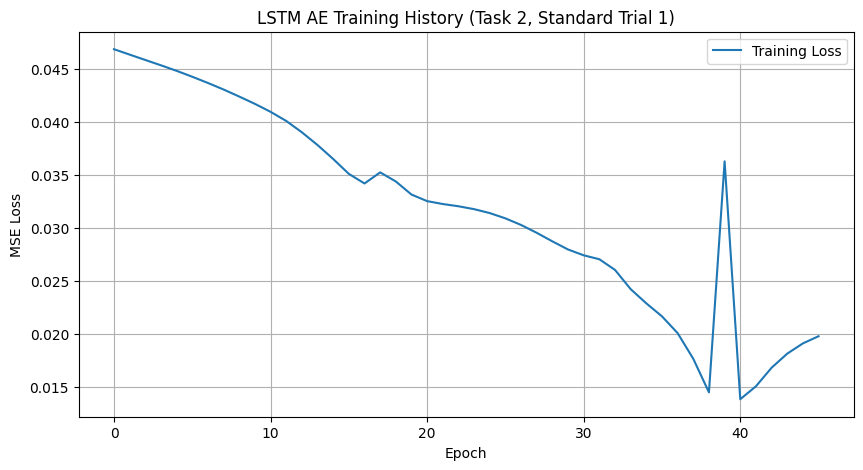


Calculating reconstruction error for current trial...
Input shape for prediction: (1, 77, 8)
Reconstruction MSE: 0.024944

--- EMG Deviation Score (LSTM AE Reconstruction Error) ---
Comparing Trial 3 against Trial 1 Standard for Task 2
Deviation Score (Reconstruction MSE): 0.024944
Higher scores indicate greater deviation from the Trial 1 pattern.
-------------------------------------------------------------

Script finished.


In [15]:
# -*- coding: utf-8 -*-
"""
Python script for analyzing biomechanical EMG data (.mat file).

This version implements Anomaly Detection using an LSTM Autoencoder,
trained on Trial 1 features as the standard, to detect deviations
in other trials of the same task based on reconstruction error.
(Fixed ValueError during training by removing validation_split for single sequence).

Requires TensorFlow: pip install tensorflow
"""

import numpy as np
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import os
# Import TensorFlow and Keras layers
try:
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError:
    print("TensorFlow not found. Please install it: pip install tensorflow")
    exit()


# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat'
JOINT_ANGLES_KEY = 'joint_angles'
EMG_KEY = 'dsfilt_emg'

# --- Task and Trial Selection ---
TASK_TO_ANALYZE = 1 # Example: Task 2 (index 1).
TRIAL_TO_ANALYZE = 2 # Example: Analyze Trial 3 (index 2) against Trial 1 standard.

# --- Feature Extraction Parameters ---
WINDOW_SIZE = 200  # In samples
WINDOW_STEP = 50   # In samples

# --- LSTM Autoencoder Parameters ---
LATENT_DIM = 16    # Number of units in LSTM layers (dimensionality of encoded representation)
EPOCHS = 50        # Number of training epochs (adjust based on performance/time)
BATCH_SIZE = 1     # We train on one sequence at a time
# VALIDATION_SPLIT removed as we train on the whole single sequence

# Muscle order: <APL,FCR,FDS,FDP,ED,EI,ECU,ECR> (0-7)

# --- Helper Functions ---

def load_mat_data(filepath, joint_key, emg_key):
    """Loads data from a .mat file."""
    # (Implementation remains the same)
    if not os.path.exists(filepath):
        print(f"Error: File not found at {filepath}")
        return None, None
    try:
        print(f"Loading data from: {filepath}")
        mat_data = loadmat(filepath)
        joint_angles_cell = None
        emg_cell = None
        if joint_key in mat_data: joint_angles_cell = mat_data[joint_key]
        if emg_key in mat_data: emg_cell = mat_data[emg_key]
        else: print(f"Error: Key '{emg_key}' not found."); return joint_angles_cell, None
        if joint_angles_cell is None and emg_cell is None: print("Error: Neither key found."); return None, None
        print("Data loading process completed.")
        return joint_angles_cell, emg_cell
    except Exception as e: print(f"An error occurred during file loading: {e}"); return None, None

def get_trial_task_data(data_cell, trial_idx, task_idx, data_type_name="Data"):
    """Extracts the data matrix for a specific trial and task."""
    # (Implementation remains the same)
    if data_cell is None: return None
    if not (0 <= trial_idx < data_cell.shape[0] and 0 <= task_idx < data_cell.shape[1]): return None
    try:
        data_matrix = data_cell[trial_idx, task_idx]
        if not isinstance(data_matrix, np.ndarray): return None
        if data_matrix.size == 0: return np.empty((0, data_cell[0,0].shape[1])) if data_cell[0,0].ndim==2 else None # Handle empty
        print(f"Extracted {data_type_name} for Trial {trial_idx+1}, Task {task_idx+1}. Shape: {data_matrix.shape}")
        return data_matrix
    except Exception as e: print(f"Error extracting {data_type_name}: {e}"); return None

def normalize_data_minmax(data_matrix, data_type_name="Data"):
    """
    Normalizes data matrix columns to the range [0, 1] using MinMaxScaler.
    Often preferred for Neural Network inputs.
    """
    # (Implementation remains the same)
    if data_matrix is None or data_matrix.ndim != 2 or data_matrix.shape[0] == 0:
        print(f"{data_type_name} MinMax normalization skipped: Invalid or empty input.")
        return None, None # Return None for scaler too
    try:
        scaler = MinMaxScaler(feature_range=(0, 1))
        normalized_data = scaler.fit_transform(data_matrix)
        print(f"{data_type_name} data normalized (MinMax). Shape: {normalized_data.shape}")
        if np.isnan(normalized_data).any():
            print(f"Warning: NaNs detected in normalized {data_type_name} data.")
        return normalized_data, scaler # Return scaler to potentially inverse transform later
    except Exception as e:
        print(f"An error occurred during {data_type_name} MinMax normalization: {e}")
        return None, None

def extract_windowed_rms_features(data_matrix, window_size, window_step, data_type_name="Data"):
    """Extracts Root Mean Square (RMS) features using sliding windows."""
    # (Implementation remains the same)
    if data_matrix is None or data_matrix.ndim != 2 or data_matrix.shape[0] < window_size:
        print(f"Feature extraction skipped for {data_type_name}: Invalid input or data shorter than window size.")
        return None
    n_samples, n_channels = data_matrix.shape
    n_windows = 1 + (n_samples - window_size) // window_step
    if n_windows <= 0:
        print(f"Feature extraction skipped for {data_type_name}: No full windows.")
        return None
    rms_features = np.zeros((n_windows, n_channels))
    print(f"Extracting RMS features for {data_type_name} ({n_windows} windows)...")
    for i in range(n_windows):
        start = i * window_step
        end = start + window_size
        window_data = data_matrix[start:end, :]
        rms_features[i, :] = np.sqrt(np.mean(window_data**2, axis=0))
    print(f"RMS features extracted for {data_type_name}. Shape: {rms_features.shape}")
    return rms_features

def build_lstm_autoencoder(timesteps, n_features, latent_dim):
    """Builds the LSTM Autoencoder model using Keras functional API."""
    # (Implementation remains the same)
    print(f"\nBuilding LSTM Autoencoder: timesteps={timesteps}, features={n_features}, latent_dim={latent_dim}")
    inputs = Input(shape=(timesteps, n_features), name='Input_Layer')
    encoder_lstm = LSTM(latent_dim, activation='relu', return_sequences=False, name='Encoder_LSTM')(inputs)
    repeater = RepeatVector(timesteps, name='Repeat_Vector')(encoder_lstm)
    decoder_lstm = LSTM(latent_dim, activation='relu', return_sequences=True, name='Decoder_LSTM')(repeater)
    outputs = TimeDistributed(Dense(n_features, activation='sigmoid'), name='Output_Layer')(decoder_lstm)
    model = Model(inputs=inputs, outputs=outputs, name='LSTM_Autoencoder')
    model.compile(optimizer='adam', loss='mse')
    print("Model built and compiled successfully.")
    model.summary()
    return model

def train_autoencoder(model, standard_features, epochs, batch_size):
    """
    Trains the LSTM Autoencoder model on the standard feature sequence.
    (Removed validation_split)

    Args:
        model (tf.keras.models.Model): The compiled LSTM autoencoder.
        standard_features (np.ndarray): Feature sequence for the standard trial (num_windows x num_features).
        epochs (int): Number of training epochs.
        batch_size (int): Batch size for training (usually 1 for single sequence AE).

    Returns:
        tf.keras.callbacks.History: Training history object.
    """
    if standard_features is None or standard_features.ndim != 2 or standard_features.shape[0] == 0:
        print("Autoencoder training skipped: Invalid standard features.")
        return None

    # Reshape data for LSTM: [samples, timesteps, features]
    n_windows, n_features = standard_features.shape
    standard_features_reshaped = standard_features.reshape((1, n_windows, n_features))

    print(f"\nTraining LSTM Autoencoder for {epochs} epochs...")
    print(f"Input shape for training: {standard_features_reshaped.shape}")

    # Early stopping callback - Monitor 'loss' instead of 'val_loss'
    early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    history = model.fit(
        standard_features_reshaped, standard_features_reshaped, # Input and target are the same for AE
        epochs=epochs,
        batch_size=batch_size,
        # validation_split=validation_split, # REMOVED
        callbacks=[early_stopping],
        shuffle=False, # Keep shuffle=False for consistency, although less critical without validation split
        verbose=1 # Show training progress
    )
    print("Training complete.")
    return history

def calculate_reconstruction_error(model, current_features):
    """Calculates the reconstruction error (MSE) for the current trial's features."""
    # (Implementation remains the same)
    if current_features is None or current_features.ndim != 2 or current_features.shape[0] == 0:
        print("Reconstruction error calculation skipped: Invalid current features.")
        return np.nan
    n_windows, n_features = current_features.shape
    current_features_reshaped = current_features.reshape((1, n_windows, n_features))
    print(f"\nCalculating reconstruction error for current trial...")
    print(f"Input shape for prediction: {current_features_reshaped.shape}")
    reconstructed_features = model.predict(current_features_reshaped, verbose=0)
    mse = np.mean(np.power(current_features_reshaped - reconstructed_features, 2))
    print(f"Reconstruction MSE: {mse:.6f}")
    return mse


# --- Main Execution ---
if __name__ == "__main__":
    print("Starting EMG Analysis Script (LSTM Autoencoder Anomaly Detection - Fixed Training)...")

    # 1. Load Data
    _, emg_cell = load_mat_data(MAT_FILE_PATH, JOINT_ANGLES_KEY, EMG_KEY)

    if emg_cell is not None:
        # 2. Extract & Normalize EMG Data for the Trial to Analyze
        print(f"\n--- Processing Trial to Analyze (Trial {TRIAL_TO_ANALYZE+1}, Task {TASK_TO_ANALYZE+1}) ---")
        current_emg_raw = get_trial_task_data(emg_cell, TRIAL_TO_ANALYZE, TASK_TO_ANALYZE, data_type_name="EMG (Current Raw)")
        current_emg_norm, _ = normalize_data_minmax(current_emg_raw, data_type_name="EMG (Current Norm)")

        # 3. Extract & Normalize Standard Data (Trial 1 of the same Task)
        print(f"\n--- Loading Standard Data (Trial 1, Task {TASK_TO_ANALYZE+1}) ---")
        standard_trial_index = 0
        standard_emg_raw = get_trial_task_data(emg_cell, standard_trial_index, TASK_TO_ANALYZE, data_type_name="EMG (Standard Raw)")
        standard_emg_norm, _ = normalize_data_minmax(standard_emg_raw, data_type_name="EMG (Standard Norm)")

        if current_emg_norm is not None and standard_emg_norm is not None:
            # 4. Extract Windowed RMS Features for both
            current_rms_features = extract_windowed_rms_features(
                current_emg_norm, WINDOW_SIZE, WINDOW_STEP, data_type_name="Current EMG"
            )
            standard_rms_features = extract_windowed_rms_features(
                standard_emg_norm, WINDOW_SIZE, WINDOW_STEP, data_type_name="Standard EMG"
            )

            if current_rms_features is not None and standard_rms_features is not None:
                 if current_rms_features.shape[1] != standard_rms_features.shape[1]:
                     print("Error: Feature dimensions mismatch between current and standard. Cannot proceed.")
                 else:
                    # 5. Build LSTM Autoencoder
                    n_windows_std, n_features_std = standard_rms_features.shape
                    lstm_autoencoder = build_lstm_autoencoder(n_windows_std, n_features_std, LATENT_DIM)

                    # 6. Train Autoencoder on Standard Data (No validation_split)
                    history = train_autoencoder(lstm_autoencoder, standard_rms_features, EPOCHS, BATCH_SIZE) # Removed validation_split arg

                    if history is not None:
                        # Optional: Plot training history (only 'loss' available)
                        plt.figure(figsize=(10, 5))
                        plt.plot(history.history['loss'], label='Training Loss')
                        # plt.plot(history.history['val_loss'], label='Validation Loss') # REMOVED
                        plt.title(f'LSTM AE Training History (Task {TASK_TO_ANALYZE+1}, Standard Trial 1)')
                        plt.ylabel('MSE Loss')
                        plt.xlabel('Epoch')
                        plt.legend()
                        plt.grid(True)
                        plt.show()

                        # 7. Calculate Reconstruction Error for Current Trial
                        if current_rms_features.shape[1] != n_features_std:
                             print("Error: Current trial features dimension mismatch after extraction. Cannot evaluate.")
                        else:
                            if current_rms_features.shape[0] != n_windows_std:
                                print("\nWarning: Number of windows in current trial "
                                      f"({current_rms_features.shape[0]}) differs from standard "
                                      f"({n_windows_std}).")
                                print("LSTM AE requires fixed timestep input. Cannot calculate reconstruction error accurately.")
                                print("Consider padding/truncating or using models robust to variable length.")
                                reconstruction_mse = np.nan
                            else:
                                reconstruction_mse = calculate_reconstruction_error(lstm_autoencoder, current_rms_features)

                            # 8. Report Deviation Score
                            print(f"\n--- EMG Deviation Score (LSTM AE Reconstruction Error) ---")
                            print(f"Comparing Trial {TRIAL_TO_ANALYZE+1} against Trial 1 Standard for Task {TASK_TO_ANALYZE+1}")
                            if np.isnan(reconstruction_mse):
                                print("Deviation Score: N/A (due to window count mismatch or other error)")
                            else:
                                print(f"Deviation Score (Reconstruction MSE): {reconstruction_mse:.6f}")
                                print("Higher scores indicate greater deviation from the Trial 1 pattern.")
                            print("-------------------------------------------------------------")
                    else:
                        print("\nAutoencoder training failed. Cannot calculate reconstruction error.")
            else:
                print("\nFeature extraction failed for current or standard data. Cannot build/train model.")
        else:
            print("\nNormalization failed for current or standard data. Cannot proceed.")
    else:
        print("\nEMG data loading failed or EMG key not found. Exiting.")

    print("\nScript finished.")


In [7]:
!pip install dtw-python